In [1]:
import prody as pr
import itertools
import bisect
import numpy as np
import gudhi
import ipywidgets as widgets
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.widgets import Slider
from matplotlib.collections import LineCollection, PatchCollection, PolyCollection
from matplotlib.patches import Circle, Polygon
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from ipywidgets import interact, FloatSlider
from scipy.spatial.distance import pdist, squareform
from IPython.display import display
from gudhi.representations import Landscape

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"]
})


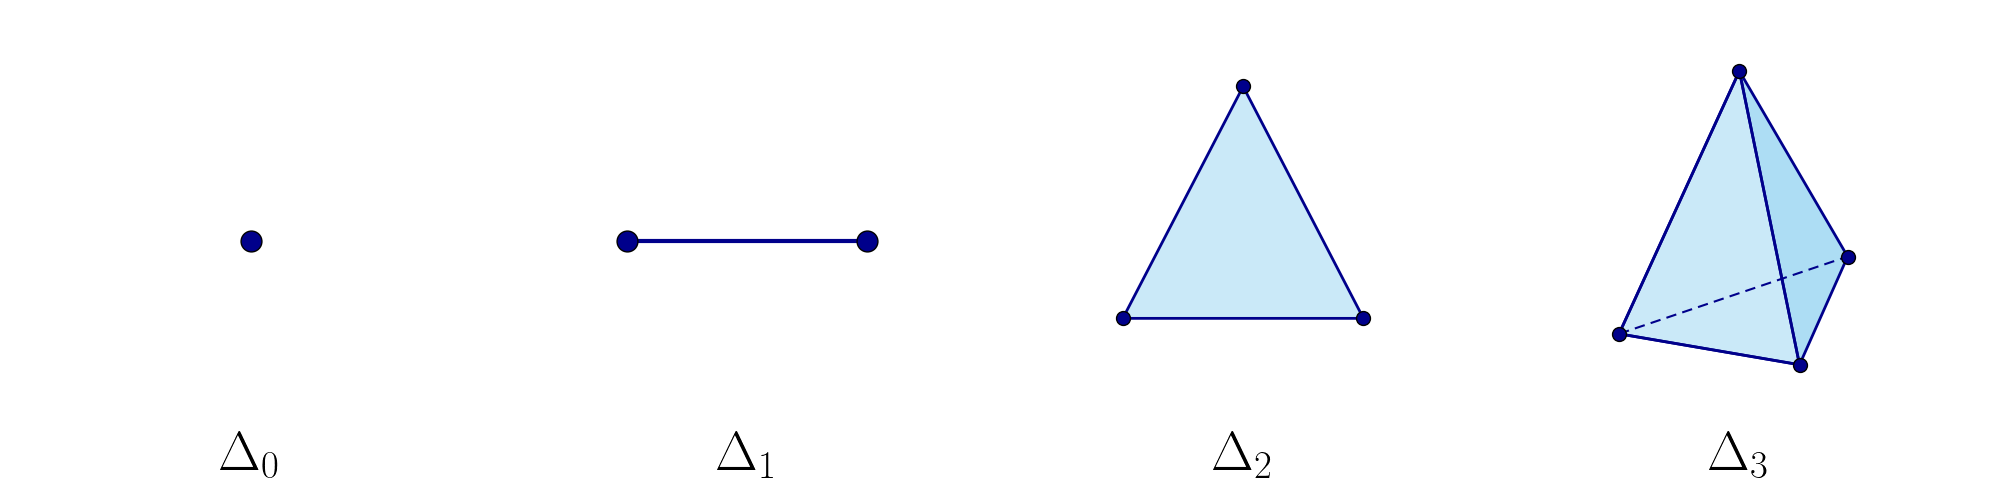

In [4]:
def plot_simplex_didatico():
    # 1 linha e 4 colunas para os sínplices de dimensão 0 a 3
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    # Cores personalizadas
    cor_face = (0.54, 0.81, 0.94, 0.45)
    cor_borda = 'darkblue'
    
    # --- Dimensão 0: Ponto ---
    axes[0].plot(0, 0, 'ko', markersize=15, markerfacecolor=cor_borda, markeredgecolor="black")
    axes[0].set_title(r"$\Delta_0$", y=-0.01,  fontsize=40)
    axes[0].set_xlim(-1, 1); axes[0].set_ylim(-1, 1)
    axes[0].axis('off')
    
    # --- Dimensão 1: Segmento ---
    axes[1].plot([-1, 1], [0, 0], 'ko', markerfacecolor=cor_borda, markeredgecolor="black", markersize=15, zorder=3)
    axes[1].plot([-1, 1], [0, 0], '-', color=cor_borda, lw=3, zorder=2)
    axes[1].set_title(r"$\Delta_1$", y=-0.01,  fontsize=40)
    axes[1].set_xlim(-2, 2); axes[1].set_ylim(-1, 1)
    axes[1].axis('off')
    
    # --- Dimensão 2: Triângulo Preenchido ---
    pts_2d = np.array([[0, 1], [-1, -0.5], [1, -0.5]])
    tri = patches.Polygon(pts_2d, closed=True, facecolor=cor_face, edgecolor=cor_borda, lw=2, zorder=2)
    axes[2].add_patch(tri)
    axes[2].plot(pts_2d[:,0], pts_2d[:,1], 'ko', markersize=10, markerfacecolor=cor_borda, markeredgecolor="black", zorder=3)
    axes[2].set_title(r"$\Delta_2$", y=-0.01,  fontsize=40)
    axes[2].set_xlim(-2, 2); axes[2].set_ylim(-1.5, 1.5)
    axes[2].axis('off')
    
    # --- Dimensão 3: Tetraedro (Representação 2D) ---
    # Vértices projetados para perspectiva 3D
    v = np.array([
        [0, 1.1],     # Vértice do topo
        [-1, -0.6],   # Vértice inferior esquerdo
        [0.5, -0.8],    # Vértice inferior direito
        [0.9, -0.1]   # Vértice interno/profundidade
    ])
    
    # Definição das faces translúcidas com a cor de borda correta
    face1 = patches.Polygon([v[0], v[1], v[3]], closed=True, facecolor=cor_face, edgecolor='none', lw=1, zorder=1)
    face2 = patches.Polygon([v[0], v[2], v[3]], closed=True, facecolor=cor_face, edgecolor='none', lw=1, zorder=1)
    face3 = patches.Polygon([v[1], v[2], v[3]], closed=True, facecolor=cor_face, edgecolor='none', lw=1, zorder=1)
    face4 = patches.Polygon([v[0], v[1], v[2]], closed=True, fill=False, edgecolor=cor_borda, lw=2, zorder=2) 
    
    axes[3].add_patch(face1)
    axes[3].add_patch(face2)
    axes[3].add_patch(face3)
    axes[3].add_patch(face4)
    
    # Arestas do tetraedro
    arestas_visiveis = [(0,1), (0,2), (0,3), (1,2), (2,3)] 
    arestas_ocultas  = [(1,3)] 
    
    # Desenha as arestas externas
    for edge in arestas_visiveis:
        axes[3].plot([v[edge[0], 0], v[edge[1], 0]], 
                     [v[edge[0], 1], v[edge[1], 1]], '-', color=cor_borda, lw=2, zorder=2)
        
    # Desenha as arestas internas pontilhadas usando a cor padrão (cor_borda)
    for edge in arestas_ocultas:
        axes[3].plot([v[edge[0], 0], v[edge[1], 0]], 
                     [v[edge[0], 1], v[edge[1], 1]], 
                     color=cor_borda, 
                     linestyle=(0, (5, 3)),  
                     lw=1.5, 
                     zorder=2)
        
    # Vértices por cima de tudo
    axes[3].plot(v[:, 0], v[:, 1], 'ko', markersize=10, markerfacecolor=cor_borda, markeredgecolor="black", zorder=4)
    
    # CORREÇÃO: Título alinhado perfeitamente embaixo (y=-0.01 igual aos outros)
    axes[3].set_title(r"$\Delta_3$", y=-0.01, fontsize=40)
    axes[3].set_xlim(-2, 2); axes[3].set_ylim(-1.5, 1.5)
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()

# Executa o plot informativo
plot_simplex_didatico()

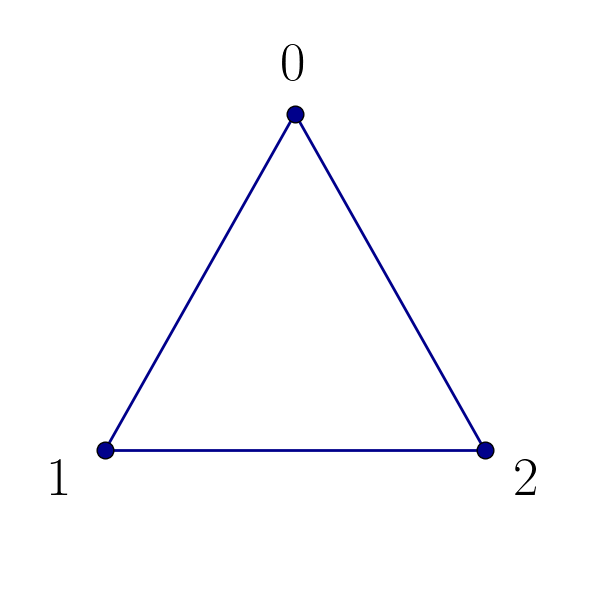

In [5]:
def plot_ex_31():
    fig, ax = plt.subplots(figsize=(6, 6))
    
    cor_borda = 'darkblue'
    # 1. Coordenadas dos 3 vértices (formato de triângulo)
    v = np.array([
        [0, 0.8],     # Vértice 0 (topo)
        [-0.8, -0.5], # Vértice 1 (inferior esquerdo)
        [0.8, -0.5]   # Vértice 2 (inferior direito)
    ])
    
    # 2. Desenhar as arestas (1-símplices) ligando os vértices
    # Conectamos: (0 a 1), (1 a 2) e (2 a 0)
    arestas = [(0, 1), (1, 2), (2, 0)]
    for edge in arestas:
        ax.plot([v[edge[0], 0], v[edge[1], 0]], 
                [v[edge[0], 1], v[edge[1], 1]], 
                color=cor_borda, linewidth=2, zorder=1)
        
    # 3. Desenhar os vértices (0-símplices) por cima das linhas
    ax.plot(v[:, 0], v[:, 1], 'ko', markersize=12, markerfacecolor=cor_borda, markeredgecolor="black", zorder=2)
    
    # 4. Enumerar os vértices (0, 1, 2) adicionando um pequeno deslocamento (offset)
    # para o texto não ficar exatamente em cima do ponto
    labels = ['0', '1', '2']
    offsets = [
        [0.0, 0.18],   # Deslocamento para cima no vértice 0
        [-0.18, -0.12], # Deslocamento para a esquerda/baixo no vértice 1
        [0.18, -0.12]   # Deslocamento para a direita/baixo no vértice 2
    ]
    
    for i in range(3):
        ax.text(v[i, 0] + offsets[i][0], 
                v[i, 1] + offsets[i][1], 
                labels[i], 
                fontsize=40, fontweight='bold', 
                ha='center', va='center')
        
    # Configurações de eixos e título didático
    # ax.set_title("Complexo Simplicial de Dimensão 1 (Não preenchido), fontsize=12, pad=15)
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.0, 1.2)
    ax.axis('off') # Remove as bordas do gráfico para foco total no elemento
    
    plt.tight_layout()
    plt.show()

plot_ex_31()

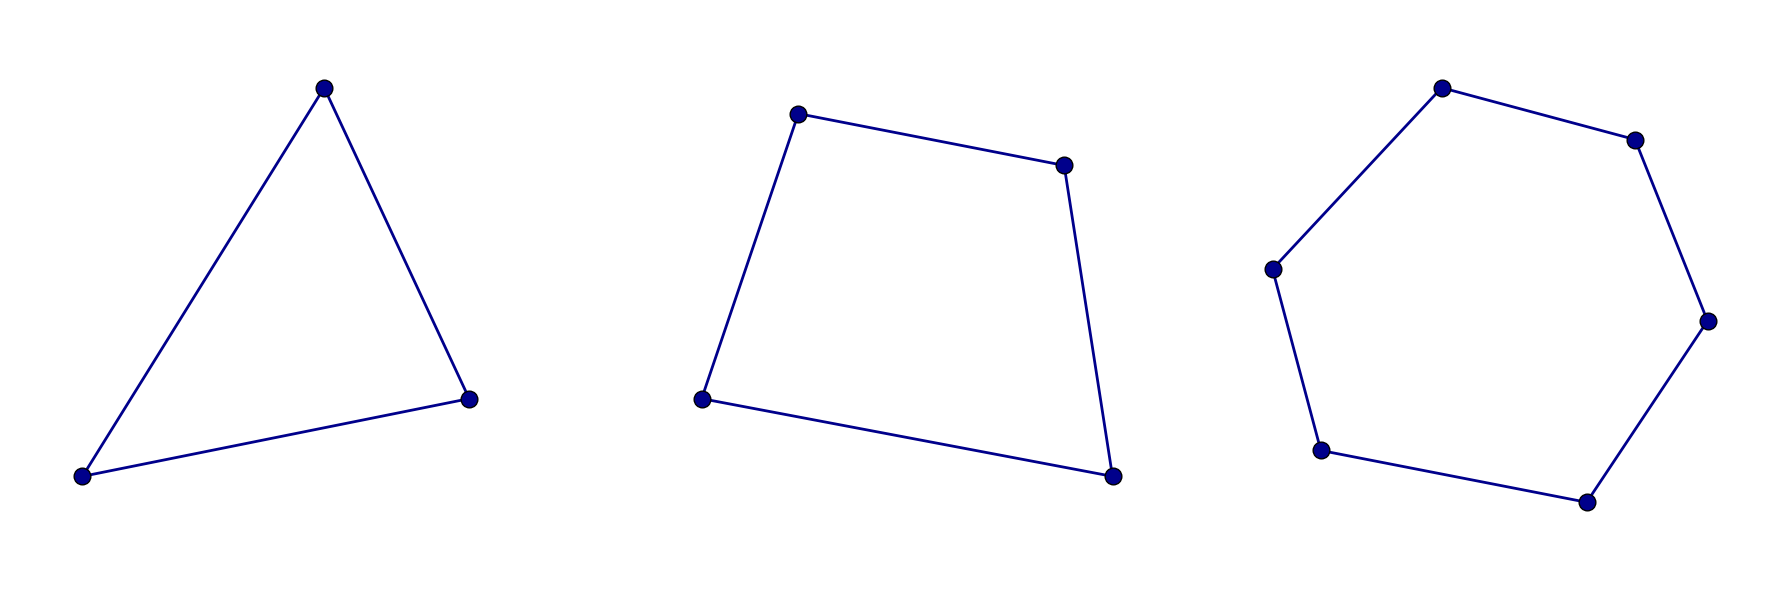

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def ex_triangulos():
    # Cria uma grade com 1 linha e 3 colunas
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    cor_borda = 'darkblue'
    
    # -------------------------------------------------------------------------
    # 1. Triângulo Escaleno (Arestas com tamanhos diferentes)
    # -------------------------------------------------------------------------
    v_tri = np.array([
        [0.1, 0.9],     # Vértice superior deslocado
        [-0.9, -0.6],   # Vértice inferior esquerdo
        [0.7, -0.3]     # Vértice inferior direito assimétrico
    ])
    
    arestas_tri = [(0, 1), (1, 2), (2, 0)]
    for edge in arestas_tri:
        axes[0].plot([v_tri[edge[0], 0], v_tri[edge[1], 0]], 
                     [v_tri[edge[0], 1], v_tri[edge[1], 1]], 
                     color=cor_borda, linewidth=2, zorder=1)
        
    axes[0].plot(v_tri[:, 0], v_tri[:, 1], 'ko', markersize=12, 
                 markerfacecolor=cor_borda, markeredgecolor="black", zorder=2)
    
    axes[0].set_xlim(-1.2, 1.2); axes[0].set_ylim(-1.0, 1.2)
    axes[0].axis('off')

    # -------------------------------------------------------------------------
    # 2. Quadrilátero Irregular (Arestas inclinadas)
    # -------------------------------------------------------------------------
    v_quad = np.array([
        [-0.4, 0.8],    # Superior esquerdo
        [0.7, 0.6],     # Superior direito inclinado
        [0.9, -0.6],    # Inferior direito
        [-0.8, -0.3]    # Inferior esquerdo totalmente inclinado
    ])
    
    # Conexões fechando o quadrilátero: 0->1->2->3->0
    arestas_quad = [(0, 1), (1, 2), (2, 3), (3, 0)]
    for edge in arestas_quad:
        axes[1].plot([v_quad[edge[0], 0], v_quad[edge[1], 0]], 
                     [v_quad[edge[0], 1], v_quad[edge[1], 1]], 
                     color=cor_borda, linewidth=2, zorder=1)
        
    axes[1].plot(v_quad[:, 0], v_quad[:, 1], 'ko', markersize=12, 
                 markerfacecolor=cor_borda, markeredgecolor="black", zorder=2)
    
    axes[1].set_xlim(-1.2, 1.2); axes[1].set_ylim(-1.0, 1.2)
    axes[1].axis('off')

    # -------------------------------------------------------------------------
    # 3. Polígono de 6 Vértices / Hexágono Irregular (Tamanhos diferentes)
    # -------------------------------------------------------------------------
    v_hex = np.array([
        [-0.2, 0.9],    # Superior 1
        [0.6, 0.7],     # Superior direito 2
        [0.9, 0.0],     # Lateral direito 3
        [0.4, -0.7],    # Inferior direito 4
        [-0.7, -0.5],   # Inferior esquerdo 5
        [-0.9, 0.2]     # Lateral esquerdo 6
    ])
    
    # Conexões fechando o hexágono: 0->1->2->3->4->5->0
    arestas_hex = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 0)]
    for edge in arestas_hex:
        axes[2].plot([v_hex[edge[0], 0], v_hex[edge[1], 0]], 
                     [v_hex[edge[0], 1], v_hex[edge[1], 1]], 
                     color=cor_borda, linewidth=2, zorder=1)
        
    axes[2].plot(v_hex[:, 0], v_hex[:, 1], 'ko', markersize=12, 
                 markerfacecolor=cor_borda, markeredgecolor="black", zorder=2)
    
    axes[2].set_xlim(-1.2, 1.2); axes[2].set_ylim(-1.0, 1.2)
    axes[2].axis('off')

    # Ajuste fino de layout para remover eixos e espaçamentos
    plt.tight_layout()
    plt.show()

ex_triangulos()

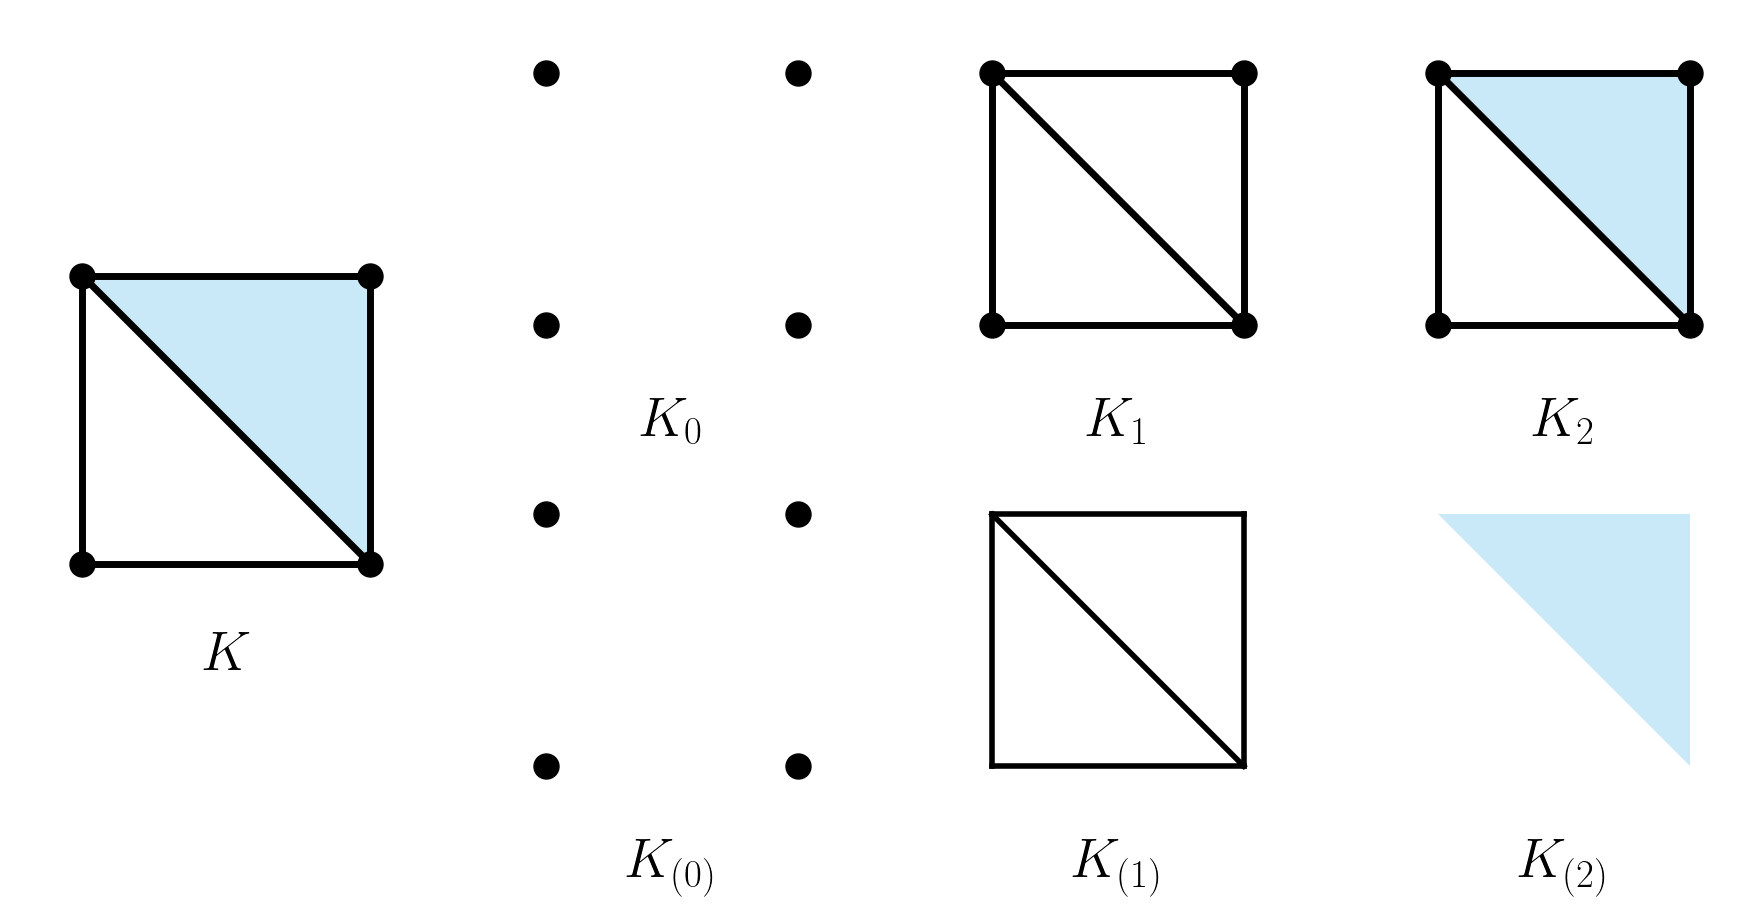

In [7]:
def plot_skeleton():
    # Cria uma figura com tamanho proporcional para o empilhamento vertical
    fig = plt.figure(figsize=(18, 9))
    
    cor_face = (0.54, 0.81, 0.94, 0.45)
    cor_borda = 'black'
    
    # Coordenadas dos 4 vértices (quadrado perfeito)
    v = np.array([
        [-0.8, 0.8],   # Vértice 0 (Superior Esquerdo)
        [0.8, 0.8],    # Vértice 1 (Superior Direito)
        [0.8, -0.8],   # Vértice 2 (Inferior Direito)
        [-0.8, -0.8]   # Vértice 3 (Inferior Esquerdo)
    ])
    
    arestas = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
    pts_triangulo = [v[0], v[1], v[2]]
    
    # Lista para aplicar as configurações de limites e eixos ao final
    all_axes = []

    # -------------------------------------------------------------------------
    # COLUNA 1: O Complexo Completo K (Ocupa as duas linhas da Coluna 0)
    # -------------------------------------------------------------------------
    ax_k = plt.subplot2grid((2, 4), (0, 0), rowspan=2)
    t1 = patches.Polygon(pts_triangulo, closed=True, facecolor=cor_face, edgecolor='none', zorder=1)
    ax_k.add_patch(t1)
    for edge in arestas:
        ax_k.plot([v[edge[0], 0], v[edge[1], 0]], [v[edge[0], 1], v[edge[1], 1]], color=cor_borda, linewidth=5, zorder=2)
    ax_k.plot(v[:, 0], v[:, 1], 'ko', markersize=18, markerfacecolor=cor_borda, markeredgecolor="black", zorder=3, lw=6)
    ax_k.set_title(r"$K$", y=-0.1, fontsize=40, fontweight='bold')
    all_axes.append(ax_k)

    # -------------------------------------------------------------------------
    # COLUNA 2: Dimensão 0 (Uma em cima da outra)
    # -------------------------------------------------------------------------
    # Linha 0, Coluna 1 -> K_0 (Pontos estruturais)
    ax_k0 = plt.subplot2grid((2, 4), (0, 1))
    ax_k0.plot(v[:, 0], v[:, 1], 'ko', markersize=18, markerfacecolor=cor_borda, markeredgecolor="black", zorder=3, lw=5)
    ax_k0.set_title(r"$K_0$", y=-0.15, fontsize=40, fontweight='bold')
    all_axes.append(ax_k0)
    
    # Linha 1, Coluna 1 -> K_{(0)} (Símplices puros de dim 0)
    ax_k0_puro = plt.subplot2grid((2, 4), (1, 1))
    ax_k0_puro.plot(v[:, 0], v[:, 1], 'ko', markersize=18, markerfacecolor=cor_borda, markeredgecolor="black", zorder=3)
    ax_k0_puro.set_title(r"$K_{(0)}$", y=-0.15, fontsize=40, fontweight='bold')
    all_axes.append(ax_k0_puro)

    # -------------------------------------------------------------------------
    # COLUNA 3: Dimensão 1 (Uma em cima da outra)
    # -------------------------------------------------------------------------
    # Linha 0, Coluna 2 -> K_1 (Vértices + Arestas)
    ax_k1 = plt.subplot2grid((2, 4), (0, 2))
    for edge in arestas:
        ax_k1.plot([v[edge[0], 0], v[edge[1], 0]], [v[edge[0], 1], v[edge[1], 1]], color=cor_borda, linewidth=5, zorder=2)
    ax_k1.plot(v[:, 0], v[:, 1], 'ko', markersize=18, markerfacecolor=cor_borda, markeredgecolor="black", zorder=3, lw=10)
    ax_k1.set_title(r"$K_1$", y=-0.15, fontsize=40, fontweight='bold')
    all_axes.append(ax_k1)
    
    # Linha 1, Coluna 2 -> K_{(1)} (Símplices puros de dim 1 - Só arestas)
    ax_k1_puro = plt.subplot2grid((2, 4), (1, 2))
    for edge in arestas:
        ax_k1_puro.plot([v[edge[0], 0], v[edge[1], 0]], [v[edge[0], 1], v[edge[1], 1]], color=cor_borda, linewidth=4, zorder=2)
    ax_k1_puro.set_title(r"$K_{(1)}$", y=-0.15, fontsize=40, fontweight='bold')
    all_axes.append(ax_k1_puro)

    # -------------------------------------------------------------------------
    # COLUNA 4: Dimensão 2 (Uma em cima da outra)
    # -------------------------------------------------------------------------
    # Linha 0, Coluna 3 -> K_2 (Igual ao K original)
    ax_k2 = plt.subplot2grid((2, 4), (0, 3))
    t2 = patches.Polygon(pts_triangulo, closed=True, facecolor=cor_face, edgecolor='none', zorder=1)
    ax_k2.add_patch(t2)
    for edge in arestas:
        ax_k2.plot([v[edge[0], 0], v[edge[1], 0]], [v[edge[0], 1], v[edge[1], 1]], color=cor_borda, linewidth=5, zorder=2)
    ax_k2.plot(v[:, 0], v[:, 1], 'ko', markersize=18, markerfacecolor=cor_borda, markeredgecolor="black", zorder=3, lw=8)
    ax_k2.set_title(r"$K_2$", y=-0.15, fontsize=40, fontweight='bold')
    all_axes.append(ax_k2)
    
    # Linha 1, Coluna 3 -> K_{(2)} (Símplices puros de dim 2 - Só o triângulo)
    ax_k2_puro = plt.subplot2grid((2, 4), (1, 3))
    t3 = patches.Polygon(pts_triangulo, closed=True, facecolor=cor_face, edgecolor='none', zorder=1)
    ax_k2_puro.add_patch(t3)
    ax_k2_puro.set_title(r"$K_{(2)}$", y=-0.15, fontsize=40, fontweight='bold')
    all_axes.append(ax_k2_puro)

    # -------------------------------------------------------------------------
    # Padronização de Limites, Proporção e Remoção de Bordas
    # -------------------------------------------------------------------------
    for ax in all_axes:
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.2, 1.2)
        ax.set_aspect('equal') # Mantém o quadrado perfeito, sem distorcer as colunas
        ax.axis('off')
    
    # Ajusta o espaçamento para não cortar as letras das fórmulas matemáticas embaixo
    plt.tight_layout(h_pad=2.0, w_pad=1.0)
    plt.show()

# Executa o plot estruturado em matriz
plot_skeleton()

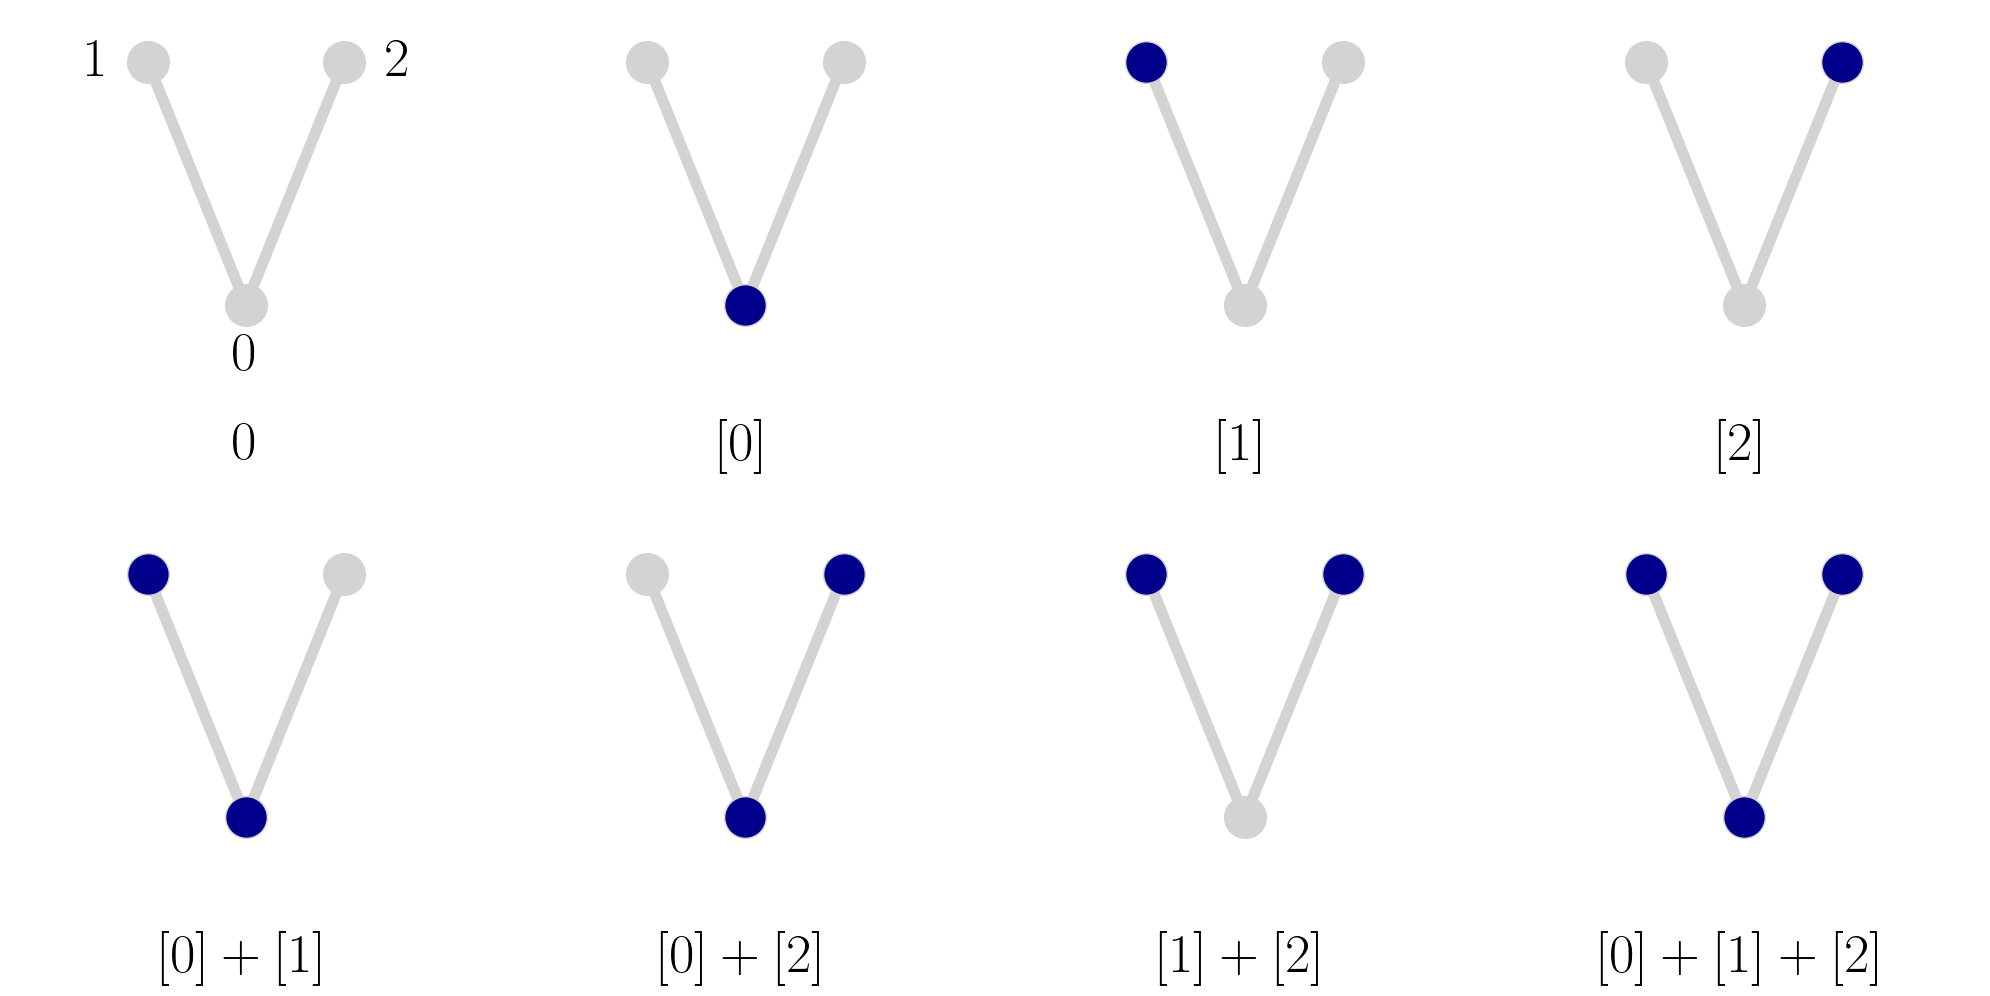

In [8]:
def plot_fases_simplexo():
    # Cria uma grade com 2 linhas e 4 colunas (8 subplots no total)
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten() # Achata a matriz para um vetor de 0 a 7
    
    # Cores solicitadas
    cor_ativa = "darkblue"
    cor_borda_ativa = 'darkblue'
    cor_apagada = "lightgray"
    cor_borda_apagada = 'lightgray'
    cor_aresta_fundo = 'lightgray'
    
    # 1. Coordenadas dos 3 vértices dispostos em formato de V
    v = np.array([
        [0.0, -0.6],    # Vértice 0 (Embaixo)
        [-0.5, 0.8],    # Vértice 1 (Ponta Superior Esquerda)
        [0.5, 0.8]      # Vértice 2 (Ponta Superior Direita)
    ])
    
    # Definição dos eixos que formam o V estrutural (0->1 e 0->2)
    arestas_fundo = [(0, 1), (0, 2)]
    
    # Títulos correspondentes a cada uma das 8 fases
    titulos = [
        "0", r"$[0]$", r"$[1]$", r"$[2]$",
        r"$[0] + [1]$", r"$[0] + [2]$", r"$[1] + [2]$", r"$[0] + [1] + [2]$"
    ]
    
    # Estados de ativação dos vértices para cada fase (True = Ativo, False = Apagado)
    # Na Fase 1 (índice 0), todos os vértices começam apagados
    estados_vertices = [
        [False, False, False], # Fase 1
        [True, False, False],  # Fase 2: vértice 0 ligado
        [False, True, False],  # Fase 3: vértice 1 ligado
        [False, False, True],  # Fase 4: vértice 2 ligado
        [True, True, False],   # Fase 5: 0 e 1 ligados
        [True, False, True],   # Fase 6: 0 e 2 ligados
        [False, True, True],   # Fase 7: 1 e 2 ligados
        [True, True, True]     # Fase 8: todos ligados
    ]
    
    # Loop para construir as 8 fases consecutivas
    for fase in range(8):
        ax = axes[fase]
        
        # A) Desenhar as arestas em cinza (apagadas em segundo plano)
        for edge in arestas_fundo:
            ax.plot([v[edge[0], 0], v[edge[1], 0]], 
                    [v[edge[0], 1], v[edge[1], 1]], 
                    color=cor_aresta_fundo, linewidth=8, linestyle='-', zorder=1)
            
        # B) Desenhar e pintar cada um dos 3 vértices conforme a regra da fase
        for i in range(3):
            esta_ativo = estados_vertices[fase][i]
            
            c_face = cor_ativa if esta_ativo else cor_apagada
            m_size = 30
            
            ax.plot(v[i, 0], v[i, 1], 'o', markersize=m_size, 
                    markerfacecolor=c_face, markeredgecolor=cor_borda_apagada, zorder=2)
            
        # C) Regra Exclusiva para a Fase 1: Enumerar os vértices desativados
        if fase == 0:
            # Vértice 0 (Embaixo)
            ax.text(v[0, 0], v[0, 1] - 0.30, '0', fontsize=40, fontweight='bold', ha='center', va='center')
            # Vértice 1 (Superior Esquerda)
            ax.text(v[1, 0] - 0.25, v[1, 1], '1', fontsize=40, fontweight='bold', ha='center', va='center')
            # Vértice 2 (Superior Direita)
            ax.text(v[2, 0] + 0.28, v[2, 1], '2', fontsize=40, fontweight='bold', ha='center', va='center')

        # Configurações do layout do gráfico e inserção do título na parte inferior
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.1, 1.1)
        ax.axis('off')
        ax.set_title(titulos[fase], y=-0.2, fontsize=40, fontweight='bold')
        
    plt.tight_layout(h_pad=4.0, w_pad=2.0)
    plt.show()

# Executa o painel com as 8 fases
plot_fases_simplexo()

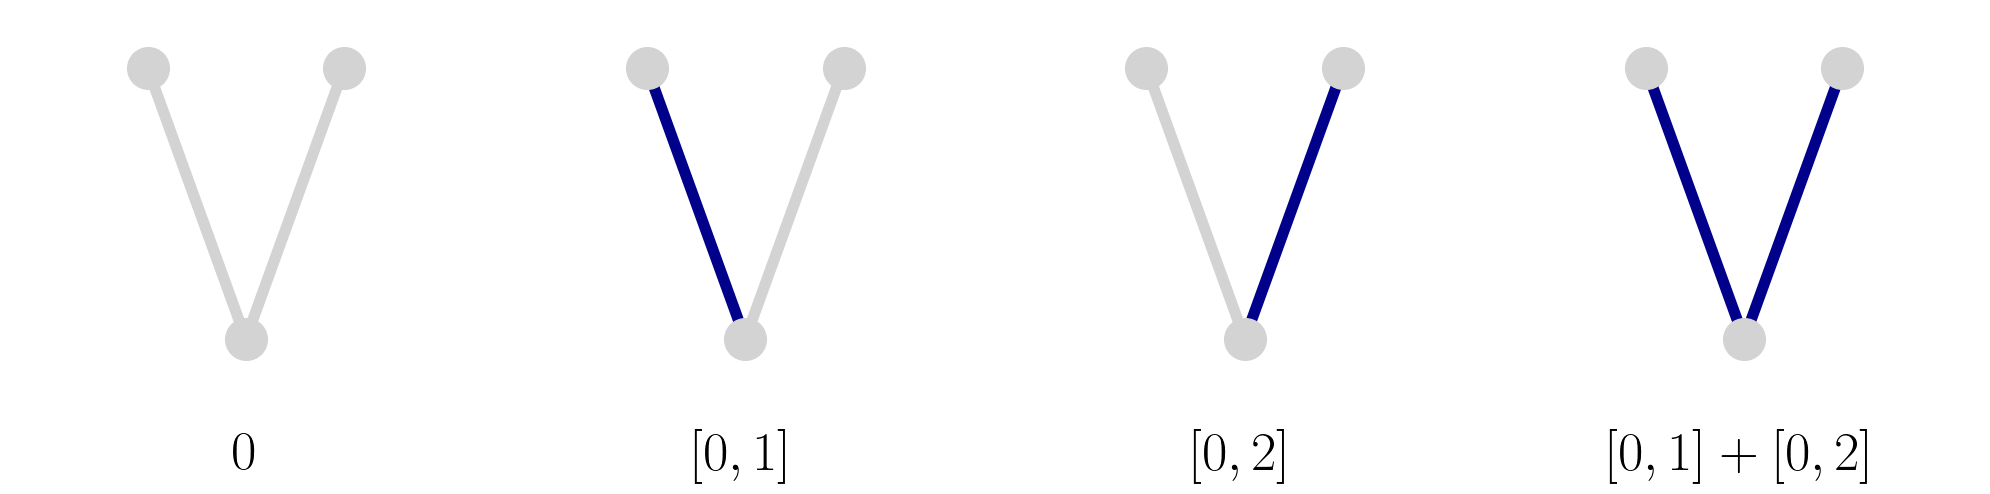

In [9]:
def plot_fases_simplexo_1():
    # Cria uma grade com 2 linhas e 4 colunas (8 subplots no total)
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes = axes.flatten() # Achata a matriz para um vetor de 0 a 7
    
    # Cores solicitadas
    cor_ativa = "darkblue"
    cor_borda_ativa = 'darkblue'
    cor_apagada = "lightgray"
    cor_borda_apagada = 'lightgray'
    cor_aresta_fundo = 'lightgray'
    
    # 1. Coordenadas dos 3 vértices dispostos em formato de V
    v = np.array([
        [0.0, -0.6],    # Vértice 0 (Embaixo)
        [-0.5, 0.8],    # Vértice 1 (Ponta Superior Esquerda)
        [0.5, 0.8]      # Vértice 2 (Ponta Superior Direita)
    ])
    
    # Definição dos eixos que formam o V estrutural (0->1 e 0->2)
    arestas = [(0, 1), (0, 2)]
    
    # Títulos correspondentes a cada uma das 8 fases
    titulos = [
        "0", r"$[0, 1]$", r"$[0, 2]$",
        r"$[0, 1] + [0, 2]$"
    ]
    
    # Estados de ativação dos vértices para cada fase (True = Ativo, False = Apagado)
    # Na Fase 1 (índice 0), todos os vértices começam apagados
    estados_vertices = [
        [False, False],
        [True, False],
        [False, True],
        [True, True]
    ]
    
    # Loop para construir as 8 fases consecutivas
    for fase in range(4):
        ax = axes[fase]
        
        # A) Desenhar as arestas em cinza (apagadas em segundo plano)
        for i,edge in enumerate(arestas):
            esta_ativo = estados_vertices[fase][i]
            c_aresta = cor_borda_ativa if esta_ativo else cor_borda_apagada
            ax.plot([v[edge[0], 0], v[edge[1], 0]], 
                    [v[edge[0], 1], v[edge[1], 1]], 
                    color=c_aresta, linewidth=8, linestyle='-', zorder=1)
            
        # B) Desenhar e pintar cada um dos 3 vértices conforme a regra da fase
        for i in range(3):
            m_size = 30
            
            ax.plot(v[i, 0], v[i, 1], 'o', markersize=m_size, 
                    markerfacecolor=cor_apagada, markeredgecolor=cor_borda_apagada, zorder=2)
            

        # Configurações do layout do gráfico e inserção do título na parte inferior
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.1, 1.1)
        ax.axis('off')
        ax.set_title(titulos[fase], y=-0.1, fontsize=40, fontweight='bold')
        
    plt.tight_layout(h_pad=4.0, w_pad=2.0)
    plt.show()

plot_fases_simplexo_1()

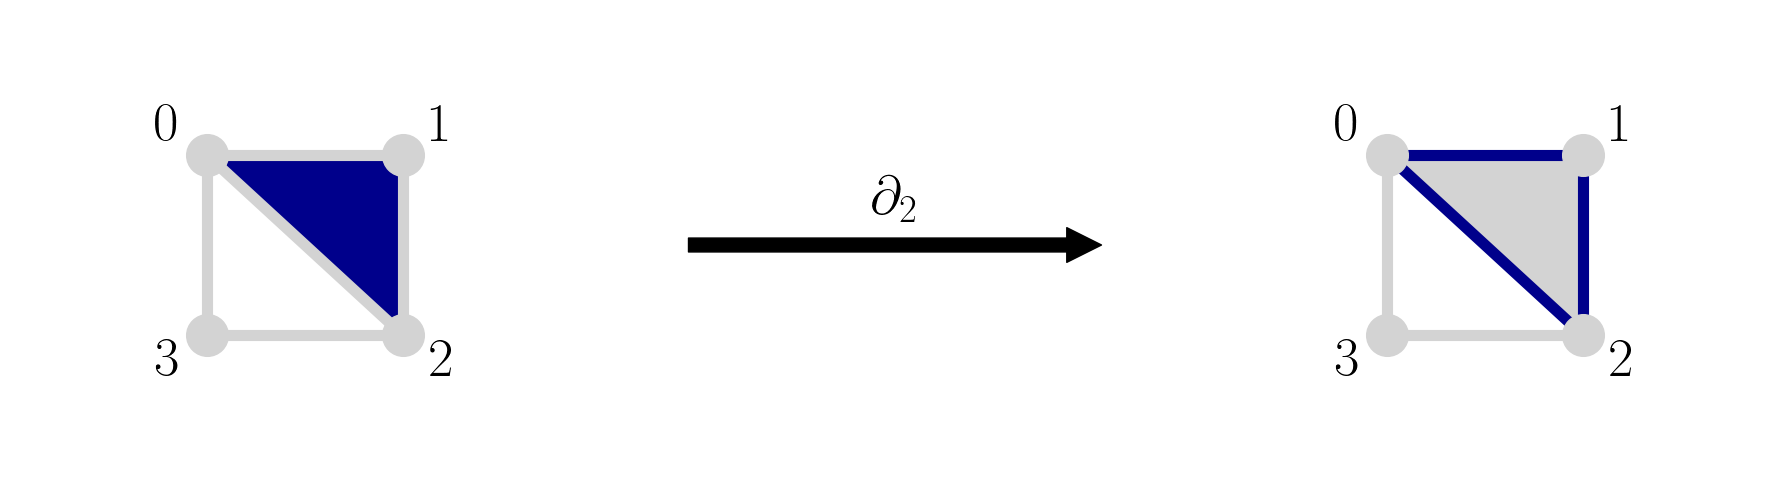

In [12]:
def plot_operador_fronteira():
    # Cria uma figura com tamanho proporcional para o empilhamento horizontal
    # (18 polegadas de largura, 8 de altura)
    fig, ax = plt.subplots(figsize=(18, 5))
    
    # Parâmetros Estéticos Solicitados
    cor_face = 'lightgray' # Vermelho translúcido (Isidoro)
    cor_borda_grau = 'lightgray'           # Cor cinza para arestas e vértices
    tamanho_fonte = 40                 # Fonte tam 40
    grosso_linha = 8                   # Linewidth 8
    grosso_vertice = 30                # Markersize 30
    
    # Coordenadas base do quadrado (centrado no eixo Y, mas deslocado no X)
    # Formato: Superior Esquerdo, Superior Direito, Inferior Direito, Inferior Esquerdo
    v_base = np.array([
        [-0.5, 0.5],   # Vértice 0
        [0.5, 0.5],    # Vértice 1
        [0.5, -0.5],   # Vértice 2
        [-0.5, -0.5]   # Vértice 3
    ])
    
    # Arestas do contorno e diagonal principal (0-1-2-3-0 + 0-2)
    arestas = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
    # Pontos do triângulo diagonal superior a ser preenchido

    # ==========================================================
    # DESENHO 1: Quadrado da ESQUERDA
    # ==========================================================
    # Coordenadas deslocadas para a esquerda (X - 3.0)
    v1 = v_base - [3.0, 0]
    pts_tri1 = [v1[0], v1[1], v1[2]]
    
    # 1.1 Preencher triângulo diagonal superior
    t1 = patches.Polygon(pts_tri1, closed=True, facecolor="darkblue", edgecolor='none', zorder=1)
    ax.add_patch(t1)
    
    # 1.2 Desenhar arestas (sólidas, cinzas, grossas)
    for edge in arestas:
        # if edge == (0,1) or edge == (0,2) or edge == (1,2):
        #     ax.plot([v1[edge[0], 0], v1[edge[1], 0]], [v1[edge[0], 1], v1[edge[1], 1]], 
        #         color="darkblue", linewidth=grosso_linha, zorder=2)
        # else:
        #     ax.plot([v1[edge[0], 0], v1[edge[1], 0]], [v1[edge[0], 1], v1[edge[1], 1]], 
        #         color=cor_borda_grau, linewidth=grosso_linha, zorder=2)
        ax.plot([v1[edge[0], 0], v1[edge[1], 0]], [v1[edge[0], 1], v1[edge[1], 1]], 
                color=cor_borda_grau, linewidth=grosso_linha, zorder=2)
        
    # 1.3 Desenhar vértices (cinzas, grandes)
    ax.plot(v1[:, 0], v1[:, 1], 'o', markersize=grosso_vertice, 
            markerfacecolor=cor_borda_grau, markeredgecolor="lightgray", zorder=3)
    
    # 1.4 Enumerar vértices (fonte 40, com offset)
    # Offset para a fonte tam 40 deve ser considerável
    offsets1 = [[-0.2, 0.15], [0.2, 0.15], [0.2, -0.15], [-0.2, -0.15]]
    labels = ['0', '1', '2', '3']
    for i in range(4):
        ax.text(v1[i, 0] + offsets1[i][0], v1[i, 1] + offsets1[i][1], labels[i], 
                fontsize=tamanho_fonte, fontweight='bold', ha='center', va='center')

    # ==========================================================
    # DESENHO 2: Seta Grande e Expressão Matemática
    # ==========================================================
    # Define a posição e tamanho da seta
    # arrowstyle='-|>' define a ponta cheia
    ax.annotate("", 
                xy=(1.5, 0),    # Fim da seta (perto do quadrado direito)
                xytext=(-1.5, 0), # Início da seta (perto do quadrado esquerdo)
                arrowprops=dict(facecolor='black', width=10, headwidth=25, headlength=25, shrink=0.15),
                zorder=1)
    # Texto (Expressão) ACIMA da seta
    expression = r"$ \partial_2$"
    ax.text(0, 0.25, expression, fontsize=tamanho_fonte, fontweight='bold', 
            ha='center', va='center', zorder=2)

    # ==========================================================
    # DESENHO 3: Quadrado da DIREITA
    # ==========================================================
    # Coordenadas deslocadas para a direita (X + 3.0)
    v2 = v_base + [3.0, 0]
    pts_tri2 = [v2[0], v2[1], v2[2]]
    
    # 3.1 Preencher triângulo diagonal superior
    t2 = patches.Polygon(pts_tri2, closed=True, facecolor=cor_face, edgecolor='none', zorder=1)
    ax.add_patch(t2)
    
    # 3.2 Desenhar arestas (sólidas, cinzas, grossas)
    for edge in arestas:
        # ax.plot([v2[edge[0], 0], v2[edge[1], 0]], [v2[edge[0], 1], v2[edge[1], 1]], 
        #         color=cor_borda_grau, linewidth=grosso_linha, zorder=2)
        if edge == (0,1) or edge == (0,2) or edge == (1,2):
            ax.plot([v2[edge[0], 0], v2[edge[1], 0]], [v2[edge[0], 1], v2[edge[1], 1]], 
                color="darkblue", linewidth=grosso_linha, zorder=2)
        else:
            ax.plot([v2[edge[0], 0], v2[edge[1], 0]], [v2[edge[0], 1], v2[edge[1], 1]], 
                color=cor_borda_grau, linewidth=grosso_linha, zorder=2)

    ax.plot(v2[:, 0], v2[:, 1], 'o', markersize=grosso_vertice,
            markerfacecolor=cor_borda_grau, markeredgecolor="lightgray", zorder=3) 
    # vertices_padrao = [2, 3]
    # ax.plot(v2[vertices_padrao, 0], v2[vertices_padrao, 1], 'o', markersize=grosso_vertice, 
    #         markerfacecolor=cor_borda_grau, markeredgecolor="lightgray", zorder=3)
    
    # vertices_coloridos = [0, 1]
    # cor_destaque = 'darkblue'
    # ax.plot(v2[vertices_coloridos, 0], v2[vertices_coloridos, 1], 'o', markersize=grosso_vertice, 
    #         markerfacecolor=cor_destaque, markeredgecolor="darkblue", zorder=3)
    
    # 3.4 Enumerar vértices (fonte 40, com offset)
    offsets2 = [[-0.2, 0.15], [0.2, 0.15], [0.2, -0.15], [-0.2, -0.15]]
    for i in range(4):
        ax.text(v2[i, 0] + offsets2[i][0], v2[i, 1] + offsets2[i][1], labels[i], 
                fontsize=tamanho_fonte, fontweight='bold', ha='center', va='center')
        

    # ==========================================================
    # Padronização de Limites, Proporção e Remoção de Bordas
    # ==========================================================
    # Expande os limites para acomodar as colunas e os números grandes
    ax.set_xlim(-4.5, 4.5)
    ax.set_ylim(-1.3, 1.3)
    
    ax.axis('off') # Remove eixos e legendas numéricas
    
    plt.tight_layout()
    plt.show()

# Executa o plot estruturado em matriz
plot_operador_fronteira()

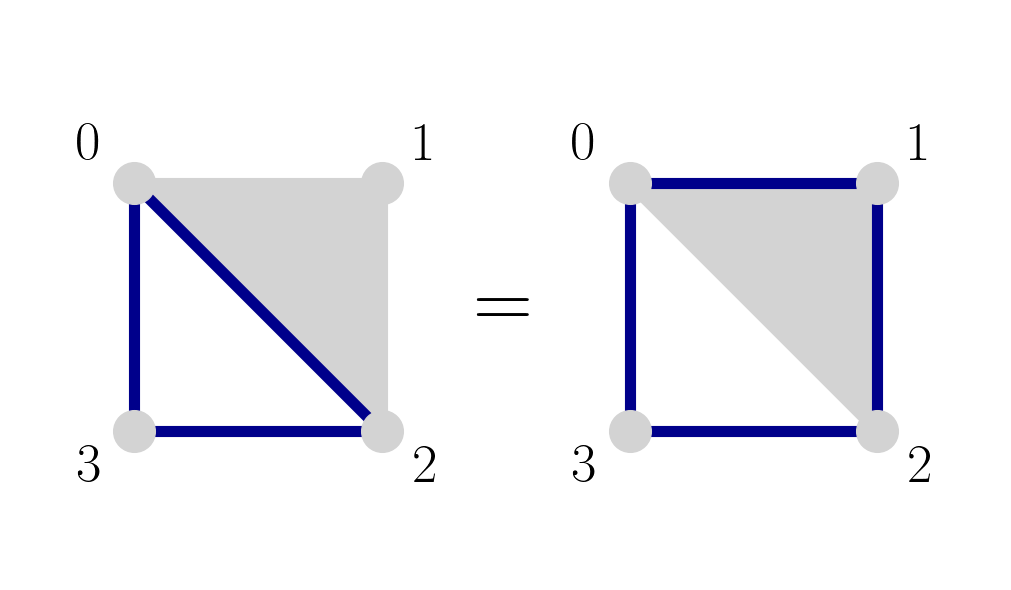

In [13]:
def plot_operador_ciclos():
    # Proporção horizontal ideal para manter os dois lados simétricos
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Parâmetros Estéticos Solicitados
    cor_face = "lightgray" # Cor azul padrão solicitada
    cor_borda_grau = 'lightgray'             # Cor cinza para elementos estruturais
    tamanho_fonte = 40                  
    grosso_linha = 8                   
    grosso_vertice = 30                
    
    # Coordenadas base do quadrado (lados de tamanho 1.0 unitário)
    v_base = np.array([
        [-0.5, 0.5],   # Vértice 0 (Superior Esquerdo)
        [0.5, 0.5],    # Vértice 1 (Superior Direito)
        [0.5, -0.5],   # Vértice 2 (Inferior Direito)
        [-0.5, -0.5]   # Vértice 3 (Inferior Esquerdo)
    ])
    
    arestas = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
    labels = ['0', '1', '2', '3']
    
    # Offsets proporcionais para afastar a fonte grande tam 40 do centro do vértice
    offsets = [[-0.18, 0.15], [0.18, 0.15], [0.18, -0.15], [-0.18, -0.15]]

    # ==========================================================
    # DESENHO 1: Quadrado da ESQUERDA (Deslocamento Simétrico -1.0)
    # ==========================================================
    v1 = v_base - [1.0, 0]
    pts_tri1 = [v1[0], v1[1], v1[2]]
    
    # 1.1 Preencher triângulo diagonal superior (2-símplice ativo)
    t1 = patches.Polygon(pts_tri1, closed=True, facecolor=cor_face, edgecolor='none', zorder=1)
    ax.add_patch(t1)
    
    # 1.2 Desenhar arestas (Esquerda: todas as linhas continuam cinzas)
    for edge in arestas:
        if edge in [(0,2), (3,0), (2,3)]:
            ax.plot([v1[edge[0], 0], v1[edge[1], 0]], [v1[edge[0], 1], v1[edge[1], 1]], 
                color="darkblue", linewidth=grosso_linha, zorder=2)
        else:
            ax.plot([v1[edge[0], 0], v1[edge[1], 0]], [v1[edge[0], 1], v1[edge[1], 1]], 
                color=cor_borda_grau, linewidth=grosso_linha, zorder=2)
        
    # 1.3 Desenhar vértices (Esquerda: todos os vértices continuam cinzas)
    ax.plot(v1[:, 0], v1[:, 1], 'o', markersize=grosso_vertice, 
            markerfacecolor=cor_borda_grau, markeredgecolor="lightgray", zorder=3)
    
    # 1.4 Enumerar vértices
    for i in range(4):
        ax.text(v1[i, 0] + offsets[i][0], v1[i, 1] + offsets[i][1], labels[i], 
                fontsize=tamanho_fonte, fontweight='bold', ha='center', va='center')

    # ==========================================================
    # DESENHO 2: Símbolo de Igual (=) e Expressão Matemática
    # ==========================================================
    # Sinal de igual perfeitamente no ponto central neutro (0,0)
    ax.text(0, 0, "=", fontsize=60, fontweight='bold', ha='center', va='center', zorder=1)
    

    # ==========================================================
    # DESENHO 3: Quadrado da DIREITA (Deslocamento Simétrico +1.0)
    # ==========================================================
    v2 = v_base + [1.0, 0]
    pts_tri2 = [v2[0], v2[1], v2[2]]
    
    # 3.1 Preencher triângulo diagonal superior (Opcional: mantido limpo ou transparente)
    t2 = patches.Polygon(pts_tri2, closed=True, facecolor=cor_face, edgecolor='none', zorder=1)
    ax.add_patch(t2)
    
    # 3.2 Desenhar arestas filtradas (Destaque para o contorno do triângulo: 0-1, 1-2, 0-2)
    for edge in arestas:
        if edge == (0, 2):
            ax.plot([v2[edge[0], 0], v2[edge[1], 0]], [v2[edge[0], 1], v2[edge[1], 1]], 
                    color=cor_borda_grau, linewidth=grosso_linha, zorder=2)
        else:
            ax.plot([v2[edge[0], 0], v2[edge[1], 0]], [v2[edge[0], 1], v2[edge[1], 1]], 
                    color="darkblue", linewidth=grosso_linha, zorder=2)
            
    ax.plot(v2[:, 0], v2[:, 1], 'o', markersize=grosso_vertice, 
            markerfacecolor=cor_borda_grau, markeredgecolor="lightgray", zorder=3)
    
    # 3.4 Enumerar vértices
    for i in range(4):
        ax.text(v2[i, 0] + offsets[i][0], v2[i, 1] + offsets[i][1], labels[i], 
                fontsize=tamanho_fonte, fontweight='bold', ha='center', va='center')

    # ==========================================================
    # Padronização de Limites, Proporção e Remoção de Bordas
    # ==========================================================
    # Estreitamos os limites para aproximar e focar nos elementos
    ax.set_xlim(-2.0, 2.0)
    ax.set_ylim(-1.1, 1.2)
    
    ax.set_aspect('equal') # Impede distorções no formato quadrado das formas
    ax.axis('off')         # Remove os eixos cartesianos numéricos do plano
    
    plt.tight_layout()
    plt.show()

# Executa o gráfico do Operador Fronteira
plot_operador_ciclos()

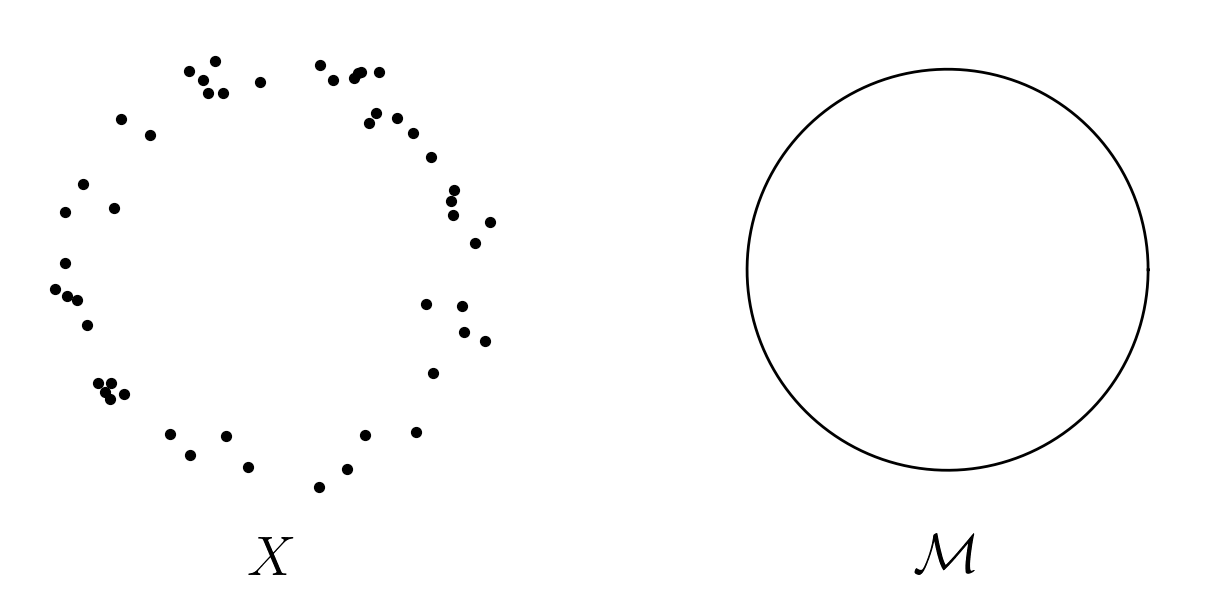

In [14]:
def plot_nuvem_e_circulo_perfeito():
    # Cria um painel com 1 linha e 2 colunas
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Configuração comum de semente para reproducibilidade
    np.random.seed(42)
    
    # ==========================================================
    # IMAGEM 1: Nuvem de 50 pontos aleatórios (Amostra com Ruído)
    # ==========================================================
    num_pontos = 50
    raio_medio = 1.0
    
    # Ângulos aleatórios entre 0 e 2*pi
    angulos = np.random.uniform(0, 2 * np.pi, num_pontos)
    # Raio com ruído gaussiano pequeno (desvio padrão de 0.08)
    ruido = np.random.normal(0, 0.08, num_pontos)
    raios_com_ruido = raio_medio + ruido
    
    # Conversão de coordenadas polares para cartesianas (X, Y)
    x_nuvem = raios_com_ruido * np.cos(angulos)
    y_nuvem = raios_com_ruido * np.sin(angulos)
    
    # Plota a nuvem de pontos (0-símplices)
    axes[0].scatter(x_nuvem, y_nuvem, color='black', s=50, zorder=2)
    
    # ==========================================================
    # IMAGEM 2: Contorno de um Círculo Perfeito (Espaço Topológico S¹)
    # ==========================================================
    # Gera 500 pontos densos e sequenciais para criar uma linha contínua e suave
    angulos_perfeitos = np.linspace(0, 2 * np.pi, 500)
    x_perfeito = raio_medio * np.cos(angulos_perfeitos)
    y_perfeito = raio_medio * np.sin(angulos_perfeitos)
    
    # Plota o contorno contínuo do círculo
    axes[1].plot(x_perfeito, y_perfeito, color='black', linewidth=2, zorder=2)
    
    # ==========================================================
    # Padronização de Limites, Proporção e Remoção de Bordas
    # ==========================================================

    titulos = [r"$X$", r"$\mathcal{M}$"]
    for i, ax in enumerate(axes):
        # Define limites ligeiramente maiores que o raio 1.0 para não cortar as bordas
        ax.set_xlim(-1.3, 1.3)
        ax.set_ylim(-1.3, 1.3)
        ax.set_aspect('equal') # Garante proporção 1:1 (evita que o círculo pareça uma elipse)
        ax.set_title(titulos[i], y=-0.1, fontsize=40, fontweight='bold')
        ax.axis('off')         # Oculta os eixos cartesianos numéricos
        
    plt.tight_layout()
    plt.show()

# Executa a geração das duas imagens lado a lado
plot_nuvem_e_circulo_perfeito()

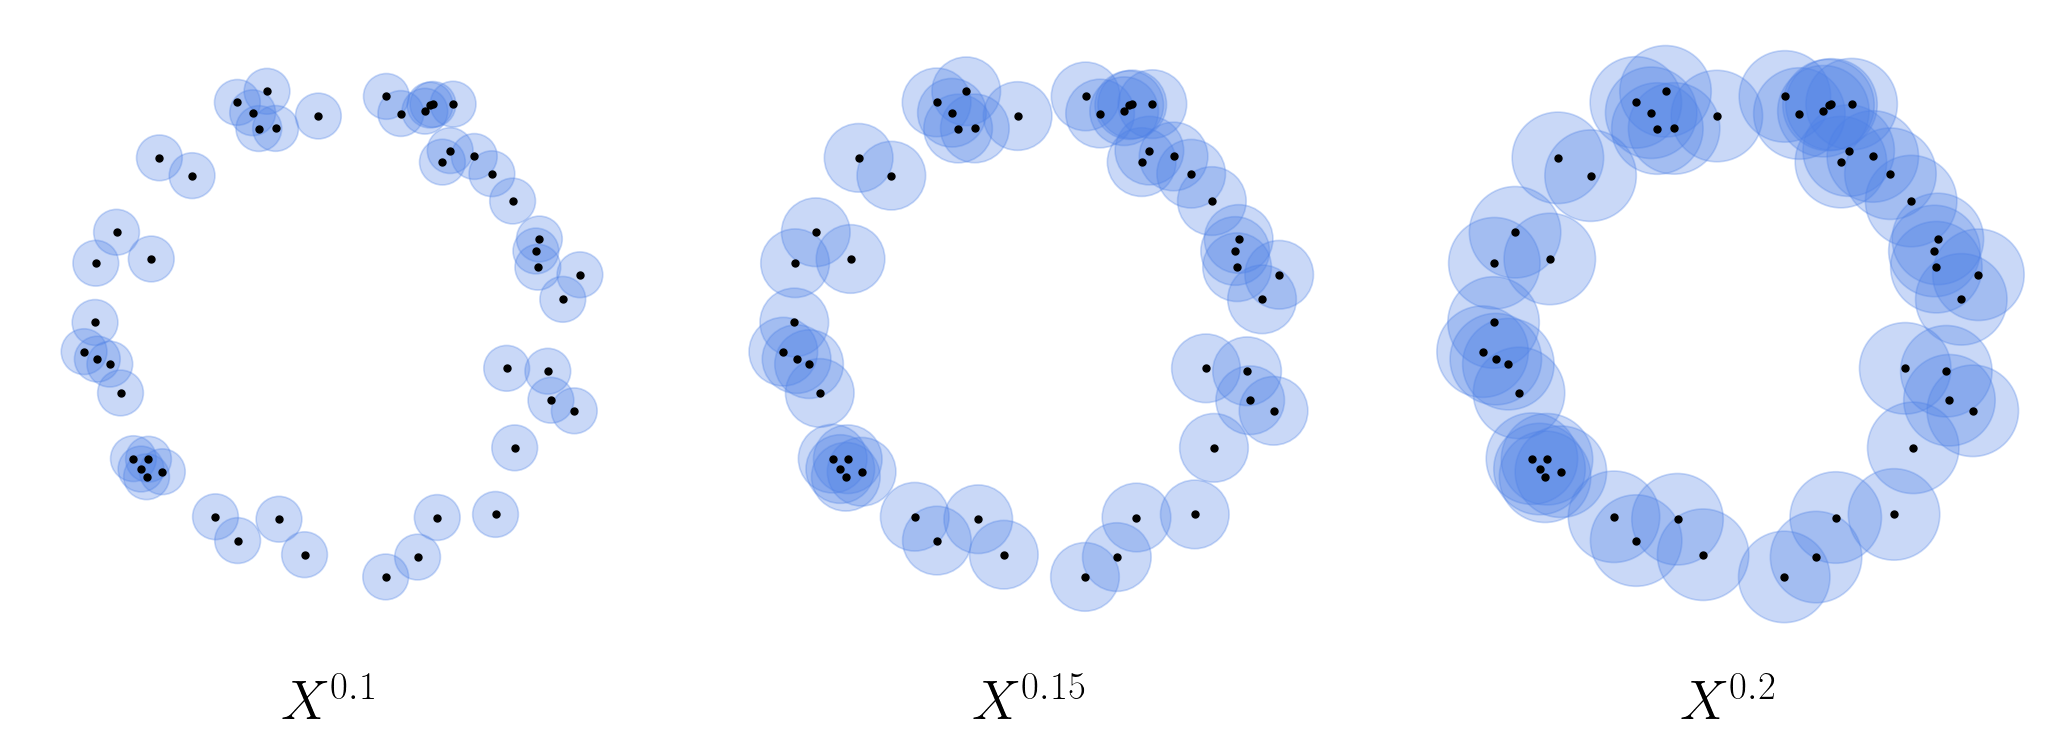

In [15]:
def plot_crescimento_esferas_tda():
    # Cria uma grade com 1 linha e 3 colunas para os raios solicitados
    fig, axes = plt.subplots(1, 3, figsize=(21, 7))
    
    # 1. Recriação exata da mesma nuvem de 50 pontos circular com ruído
    np.random.seed(42)
    num_pontos = 50
    raio_medio = 1.0
    angulos = np.random.uniform(0, 2 * np.pi, num_pontos)
    ruido = np.random.normal(0, 0.08, num_pontos)
    raios_com_ruido = raio_medio + ruido
    
    x_nuvem = raios_com_ruido * np.cos(angulos)
    y_nuvem = raios_com_ruido * np.sin(angulos)
    
    # Lista com as configurações dos raios das bolas
    raios_bolas = [0.1, 0.15, 0.2]
    titulos = [r"$X^{0.1}$", r"$X^{0.15}$", r"$X^{0.2}$"]
    cor = (0.3, 0.5, 0.9, 0.3)
    # Loop para construir cada uma das 3 fases de crescimento das esferas
    for i in range(3):
        ax = axes[i]
        raio_atual = raios_bolas[i]
        
        # A) Desenhar as bolas (esferas translúcidas) centradas em cada ponto
        for px, py in zip(x_nuvem, y_nuvem):
            # Usando uma cor leve de preenchimento (cinza) com contorno sutil
            bola = plt.Circle((px, py), raio_atual, 
                              facecolor=cor, 
                              edgecolor=cor, 
                              linewidth=1.2, zorder=1)
            ax.add_patch(bola)
            
        # B) Desenhar os pontos centrais (0-símplices) por cima das esferas
        ax.scatter(x_nuvem, y_nuvem, color='black', s=25, zorder=2)
        
        # C) Configurações de exibição e títulos posicionados embaixo
        ax.set_xlim(-1.4, 1.4)
        ax.set_ylim(-1.4, 1.4)
        ax.set_aspect('equal') # Mantém a proporção 1:1 sem achatar o círculo
        ax.axis('off')         # Remove as bordas padrão do gráfico do matplotlib
        ax.set_title(titulos[i], y=-0.12, fontsize=40, fontweight='bold')
        
    plt.tight_layout(w_pad=2.0)
    plt.show()

# Executa o plot das 3 imagens de filtração
plot_crescimento_esferas_tda()

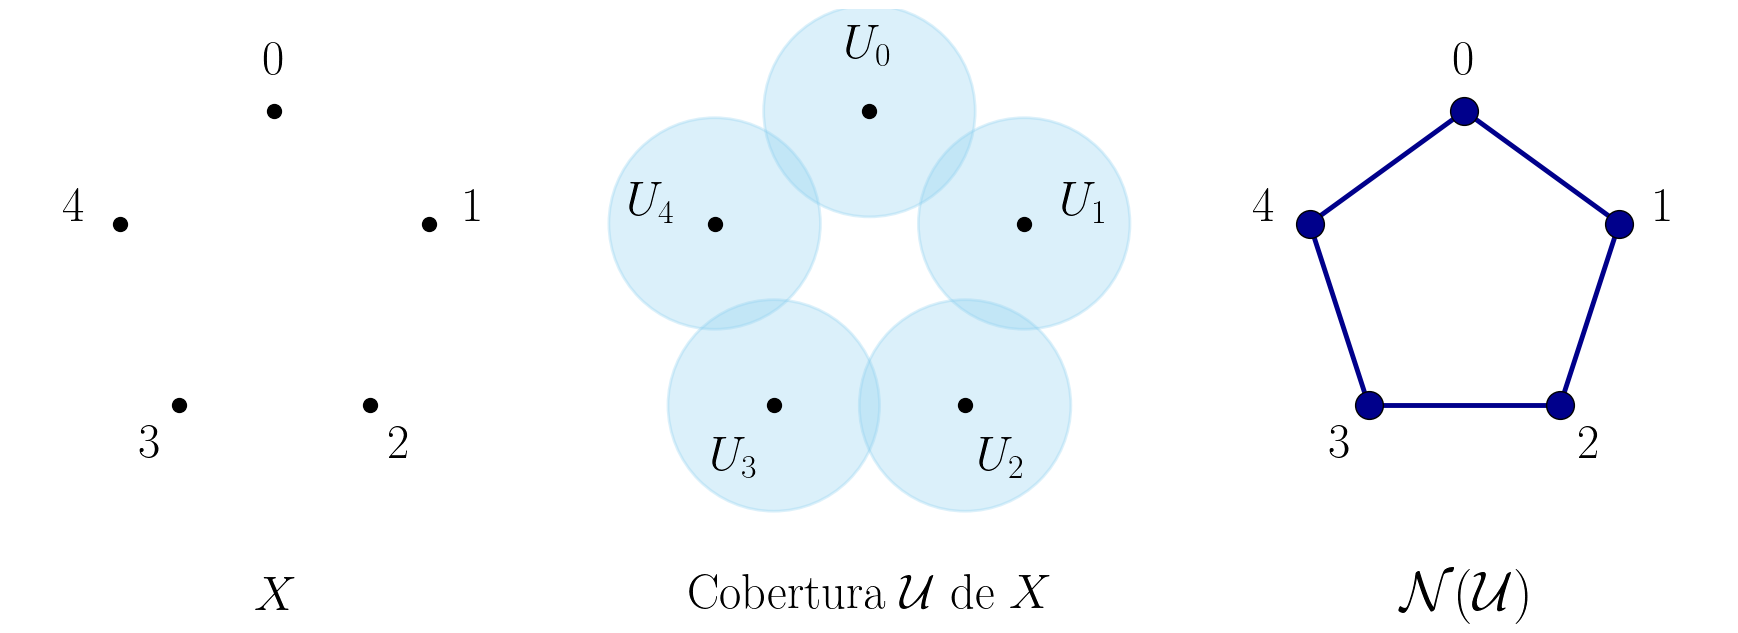

In [16]:
def plot_nuvem_cobertura_nervo():
    # Cria uma grade horizontal com 1 linha e 3 colunas
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Coordenadas de 5 pontos distribuídos em um círculo de raio 0.8
    angulos = np.linspace(0, 2 * np.pi, 5, endpoint=False)
    v = np.column_stack((0.8 * np.sin(angulos), 0.8 * np.cos(angulos)))
    
    labels = ['0', '1', '2', '3', '4']
    
    # Parâmetros estéticos (Mantendo o padrão azul translúcido e darkblue do seu trabalho)
    cor_bola = (0.54, 0.81, 0.94, 0.3)
    cor_borda_bola = (0.54, 0.81, 0.94, 0.3)
    cor_nervo = 'darkblue'
    
    # Raio crítico calculado: as arestas vizinhas medem 0.94, então r=0.52 garante 
    # que vizinhos se intersectam (2r = 1.04 > 0.94), mas não vizinhos não se tocam.
    raio = 0.52 
    
    # -------------------------------------------------------------------------
    # COLUNA 1: Nuvem de Pontos (Espaço Topológico Discreto X)
    # -------------------------------------------------------------------------
    axes[0].plot(v[:, 0], v[:, 1], 'ko', markersize=10, zorder=2)
    # Rótulos numéricos dos pontos
    for i in range(5):
        axes[0].text(v[i, 0] * 1.3, v[i, 1] * 1.3, labels[i], 
                     fontsize=35, fontweight='bold', ha='center', va='center')
    axes[0].set_title("$X$", y=-0.15, fontsize=35, fontweight='bold')
    
    # -------------------------------------------------------------------------
    # COLUNA 2: Cobertura de X (Coleção de abertos U_i satisfazendo seu LaTeX)
    # -------------------------------------------------------------------------
    axes[1].plot(v[:, 0], v[:, 1], 'ko', markersize=10, zorder=3)
    for i in range(5):
        # Cria e adiciona cada bola aberta U_i centralizada no ponto
        bola = patches.Circle((v[i, 0], v[i, 1]), raio, facecolor=cor_bola, 
                              edgecolor=cor_borda_bola, linewidth=2, zorder=1)
        axes[1].add_patch(bola)
        # Identificação de cada subconjunto aberto U_i
        axes[1].text(v[i, 0] * 1.4, v[i, 1] * 1.4, f"$U_{labels[i]}$", 
                     fontsize=35, fontweight='bold', ha='center', va='center', zorder=4)
    axes[1].set_title(r"Cobertura $\mathcal{U}$ de $X$", y=-0.15, fontsize=35, fontweight='bold')
    
    # -------------------------------------------------------------------------
    # COLUNA 3: O Nervo de X (Complexo Simplicial N(U))
    # -------------------------------------------------------------------------
    # Desenha os 0-símplices (vértices do Nervo mapeados nos centros)
    axes[2].plot(v[:, 0], v[:, 1], 'ko', markersize=20, zorder=3, 
                 markerfacecolor=cor_nervo, markeredgecolor='black')
    
    # Aplicação algorítmica da sua Definição: Se U_i ∩ U_j != vazio, adicione 1-símplice
    # Geometricamente, se a distância entre centros for <= 2 * raio, as bolas se intersectam.
    for i in range(5):
        for j in range(i + 1, 5):
            distancia = np.linalg.norm(v[i] - v[j])
            if distancia <= 2 * raio:
                axes[2].plot([v[i, 0], v[j, 0]], [v[i, 1], v[j, 1]], 
                             color=cor_nervo, linewidth=3.5, zorder=2)
                
    for i in range(5):
        axes[2].text(v[i, 0] * 1.3, v[i, 1] * 1.3, labels[i], 
                     fontsize=35, fontweight='bold', ha='center', va='center')
        
    axes[2].set_title(r"$\mathcal{N}(\mathcal{U})$", y=-0.15, fontsize=40, fontweight='bold')
    
    # -------------------------------------------------------------------------
    # Padronização de Layout de todos os Subplots
    # -------------------------------------------------------------------------
    for ax in axes:
        ax.set_xlim(-1.3, 1.3)
        ax.set_ylim(-1.3, 1.3)
        ax.set_aspect('equal') # Mantém a proporção circular perfeita
        ax.axis('off')         # Oculta grades e eixos numéricos cartesianos
        
    plt.tight_layout()
    plt.show()

# Executa a função didática
plot_nuvem_cobertura_nervo()

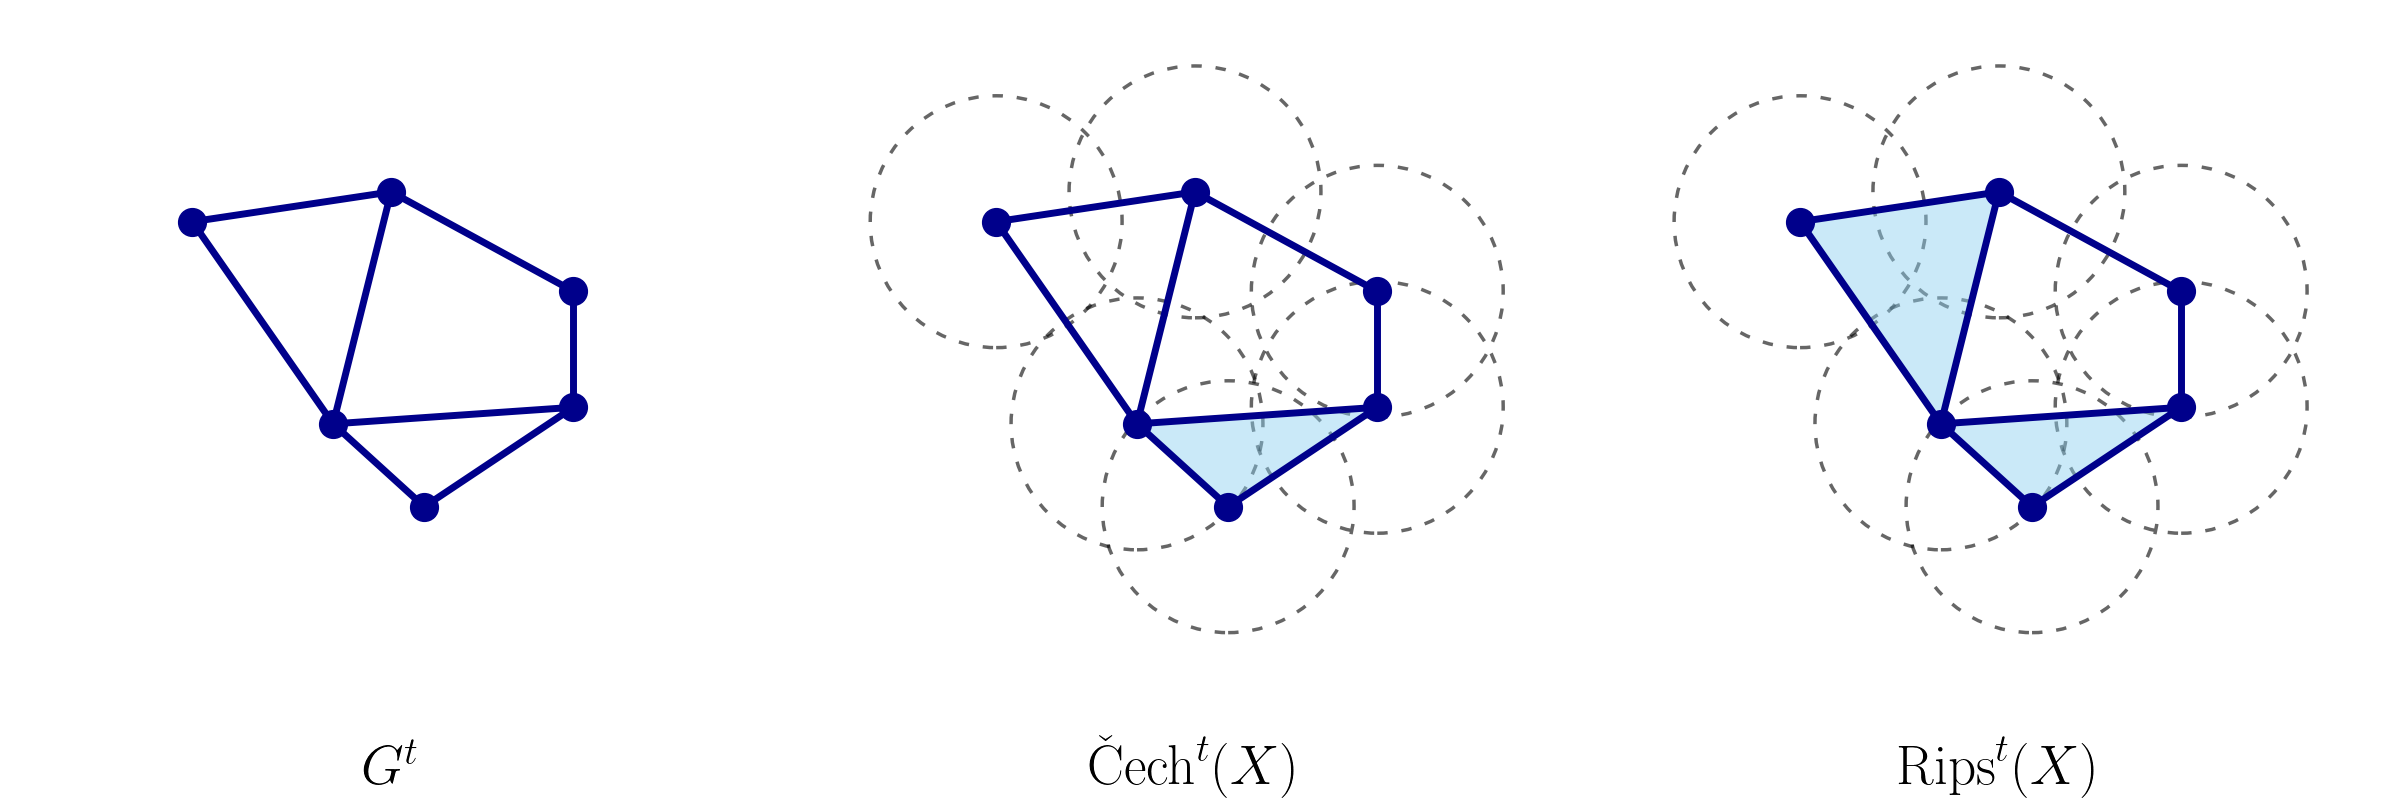

In [17]:
def plot_cech_vs_rips():
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    
    # Paleta de Cores e Estilos Solicitados
    cor_azul_preenchimento = (0.54, 0.81, 0.94, 0.45)
    cor_azul_solida = 'darkblue'
    
    grosso_linha = 5
    grosso_vertice = 20
    tamanho_titulo = 40
    
    # 1. Matriz preservando os seus 6 pontos exatos informados
    v = np.array([
        [-0.35, 0.0],    # Ponto 0 -> índice 0 no código
        [0.2, -0.5],   # Ponto 3 -> índice 1 no código
        [-1.2, 1.22],    # Ponto 4 -> índice 2 no código
        [1.1, 0.8],     # Ponto 6 -> índice 3 no código
        [1.1, 0.1],     # Ponto 7 -> índice 4 no código
        [0.0, 1.4]      # Ponto 8 -> índice 5 no código
    ])
    
    # Mapeamento das arestas para os dois triângulos distintos solicitados:
    # Triângulo Superior formado por 8, 4 e 0  -> índices (5, 2, 0)
    # Triângulo Inferior formado por 0, 3 e 7   -> índices (0, 1, 4)
    arestas = [
        (5, 2), (2, 0), (5, 0),  # Triângulo Superior (8, 4, 0)
        (0, 1), (1, 4), (0, 4),   # Triângulo Inferior (0, 3, 7)
        (3,4),
        (3,5)
    ]
    
    triangulo_superior = [v[5], v[2], v[0]]
    triangulo_inferior  = [v[0], v[1], v[4]]
    

    raio_bola = 0.76

    # -------------------------------------------------------------------------
    # IMAGEM 1: O Grafo G^t (Dois triângulos nítidos e vazios)
    # -------------------------------------------------------------------------
    for edge in arestas:
        axes[0].plot([v[edge[0], 0], v[edge[1], 0]], [v[edge[0], 1], v[edge[1], 1]], 
                     color=cor_azul_solida, linewidth=grosso_linha, zorder=2)
        
    axes[0].plot(v[:, 0], v[:, 1], 'o', markersize=grosso_vertice, 
                 markerfacecolor=cor_azul_solida, markeredgecolor=cor_azul_solida, zorder=3)
    
    axes[0].set_title(r"$G^t$", y=-0.05, fontsize=tamanho_titulo, fontweight='bold')

    # -------------------------------------------------------------------------
    # IMAGEM 2: O Complexo de Čech^t(X) (Apenas o triângulo superior preenchido)
    # -------------------------------------------------------------------------
    # Contorno pontilhado largo para as 6 esferas abertas
    for i in range(6):
        bola = patches.Circle((v[i, 0], v[i, 1]), raio_bola, fill=False, 
                              edgecolor='black', linestyle=(0, (3, 4)), linewidth=2.5, alpha=0.6, zorder=1)
        axes[1].add_patch(bola)
        
    # Preenchimento do 2-símplice superior (onde há interseção tripla comum no centro)
    t_cech = patches.Polygon(triangulo_inferior, closed=True, facecolor=cor_azul_preenchimento, edgecolor='none', zorder=2)
    axes[1].add_patch(t_cech)
    
    for edge in arestas:
        axes[1].plot([v[edge[0], 0], v[edge[1], 0]], [v[edge[0], 1], v[edge[1], 1]], 
                     color=cor_azul_solida, linewidth=grosso_linha, zorder=3)
        
    axes[1].plot(v[:, 0], v[:, 1], 'o', markersize=grosso_vertice, 
                 markerfacecolor=cor_azul_solida, markeredgecolor=cor_azul_solida, zorder=4)
    
    axes[1].set_title(r"$\check{\mathrm{C}}\mathrm{ech}^t(X)$", y=-0.05, fontsize=tamanho_titulo, fontweight='bold')

    # -------------------------------------------------------------------------
    # IMAGEM 3: O Complexo de Rips^t(X) (Ambos os triângulos preenchidos)
    # -------------------------------------------------------------------------
    # Contorno pontilhado largo para as 6 esferas abertas
    for i in range(6):
        bola = patches.Circle((v[i, 0], v[i, 1]), raio_bola, fill=False, 
                              edgecolor='black', linestyle=(0, (3, 4)), linewidth=2.5, alpha=0.6, zorder=1)
        axes[2].add_patch(bola)
        
    # Preenche ambos os triângulos (Rips preenche pois todas as arestas par a par existem)
    t_rips1 = patches.Polygon(triangulo_superior, closed=True, facecolor=cor_azul_preenchimento, edgecolor='none', zorder=2)
    t_rips2 = patches.Polygon(triangulo_inferior, closed=True, facecolor=cor_azul_preenchimento, edgecolor='none', zorder=2)
    axes[2].add_patch(t_rips1)
    axes[2].add_patch(t_rips2)
    
    for edge in arestas:
        axes[2].plot([v[edge[0], 0], v[edge[1], 0]], [v[edge[0], 1], v[edge[1], 1]], 
                     color=cor_azul_solida, linewidth=grosso_linha, zorder=3)
        
    axes[2].plot(v[:, 0], v[:, 1], 'o', markersize=grosso_vertice, 
                 markerfacecolor=cor_azul_solida, markeredgecolor=cor_azul_solida, zorder=4)
    
    axes[2].set_title(r"$\mathrm{Rips}^t(X)$", y=-0.05, fontsize=tamanho_titulo, fontweight='bold')

    # -------------------------------------------------------------------------
    # Padronização de Limites, Proporção e Ocultação dos Eixos Cartesianos
    # -------------------------------------------------------------------------
    for ax in axes:
        ax.set_xlim(-2.3, 2.3)
        ax.set_ylim(-2.0, 2.5)
        ax.set_aspect('equal')
        ax.axis('off')
        
    plt.tight_layout(w_pad=3.0)
    plt.show()

# Executa o plot das subcamadas simpliciais
plot_cech_vs_rips()

In [118]:
protein = pr.parseMMCIF(r"Dados\dataset\apo\1omp.cif.gz")
        
calphas = protein.select("calpha and chain A")
coordenadas = calphas.getCoords()

In [119]:
fonte_latex = dict(
    family="Cambria, 'Times New Roman', 'Computer Modern', serif",
    size=40,
    color="black"
)

fig_global = None
simplices_global = []
X_g, Y_g, Z_g = None, None, None
filtracoes_global = []

def plot_rips_3d(coordenadas, d_max=12.0):
    global fig_global, slider_global, simplices_global, X_g, Y_g, Z_g, filtracoes_global
 
    # .tolist() é o ponto-chave: nunca passar ndarray cru para as traces
    # de um FigureWidget, só listas Python.
    X_g = coordenadas[:, 0].tolist()
    Y_g = coordenadas[:, 1].tolist()
    Z_g = coordenadas[:, 2].tolist()
 
    rips = gudhi.RipsComplex(points=coordenadas, max_edge_length=d_max)
    st = rips.create_simplex_tree(max_dimension=3)
    simplices_global = sorted(st.get_simplices(), key=lambda sf: sf[1])
    filtracoes_global = [f for _, f in simplices_global]
 
    fig_global = go.FigureWidget()
    fig_global.add_trace(go.Scatter3d(x=X_g, y=Y_g, z=Z_g, mode='markers',
                                       marker=dict(size=4, color='black'), name='0-Símplices'))
    fig_global.add_trace(go.Scatter3d(x=[], y=[], z=[], mode='lines',
                                       line=dict(color='gray', width=2), name='1-Símplices'))
    fig_global.add_trace(go.Mesh3d(x=X_g, y=Y_g, z=Z_g, i=[], j=[], k=[],
                                    color='rgba(255, 255, 0, 0.2)', name='2-Símplices'))
    fig_global.add_trace(go.Mesh3d(x=X_g, y=Y_g, z=Z_g, i=[], j=[], k=[],
                                    color='rgba(144, 238, 144, 0.3)', name='3-Símplices'))
 
    fig_global.update_layout(
        scene=dict(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False, bgcolor='rgba(0,0,0,0)'),
        showlegend=False,
        title=dict(text="d = 0.0 Å", y=0.05, x=0.5,
                   xanchor='center', yanchor='bottom', font=fonte_latex),
        margin=dict(l=0, r=0, b=40, t=10),
        height=600
    )
 
    slider_global = widgets.FloatSlider(
        value=0.0, min=0.0, max=d_max, step=0.1,
        description='Distância (Å):',
        continuous_update=False,
        layout=widgets.Layout(width='80%')
    )
 
    def atualizar_grafico(change):
        d = change.new
        idx = bisect.bisect_right(filtracoes_global, d)

        edges_x, edges_y, edges_z = [], [], []
        tri_i, tri_j, tri_k = [], [], []
        tet_i, tet_j, tet_k = [], [], []

        for simplex, _ in simplices_global[:idx]:
            dim = len(simplex) - 1
            if dim == 1:
                a, b = simplex
                edges_x.extend([X_g[a], X_g[b], None])
                edges_y.extend([Y_g[a], Y_g[b], None])
                edges_z.extend([Z_g[a], Z_g[b], None])
            elif dim == 2:
                tri_i.append(simplex[0]); tri_j.append(simplex[1]); tri_k.append(simplex[2])
            elif dim == 3:
                a, b, c, e = simplex
                tet_i.extend([a, a, a, b])
                tet_j.extend([b, b, c, c])
                tet_k.extend([c, e, e, e])
        print("Testando")
        print(len(tri_i), len(tet_i))
        with fig_global.batch_update():
            if d >= 4.0:
                fig_global.data[0].x, fig_global.data[0].y, fig_global.data[0].z = [], [], []
            else:
                fig_global.data[0].x, fig_global.data[0].y, fig_global.data[0].z = X_g, Y_g, Z_g
            fig_global.data[1].x, fig_global.data[1].y, fig_global.data[1].z = edges_x, edges_y, edges_z
            fig_global.data[2].i, fig_global.data[2].j, fig_global.data[2].k = tri_i, tri_j, tri_k
            fig_global.data[3].i, fig_global.data[3].j, fig_global.data[3].k = tet_i, tet_j, tet_k
            fig_global.layout.title.text = f"d = {d:.1f} Å"
 
    slider_global.observe(atualizar_grafico, names='value')
    display(widgets.VBox([slider_global, fig_global]))
 
 
def salvar_png(nome_base="rips_protein", scale=4, width=1000, height=1000):
    if fig_global is None or slider_global is None:
        print("Rode plot_rips_3d primeiro.")
        return
    nome = f"{nome_base}.png".replace(' ', '_').replace('Å', '')
    fig_estatica = go.Figure(fig_global)
    for trace in fig_estatica.data:
        if trace.type == 'mesh3d':
            trace.opacity = 1.0  # kaleido não exporta alpha de Mesh3d de forma confiável
    fig_estatica.write_image(nome, scale=scale, width=width, height=height)
    print(f"Salvo: {nome}")
 
 
campo_nome = widgets.Text(value='rips_protein', description='Nome:')
botao_salvar = widgets.Button(description='Salvar PNG', button_style='success')
saida_salvar = widgets.Output()
 
 
def _on_click_salvar(b):
    with saida_salvar:
        saida_salvar.clear_output()
        salvar_png(nome_base=campo_nome.value)
 
 
botao_salvar.on_click(_on_click_salvar)
# 1. Executa o plot interativo
plot_rips_3d(coordenadas)
 
# 2. Exibe o controle de salvamento (usa o d atual do slider acima)
display(widgets.HBox([campo_nome, botao_salvar]), saida_salvar)

Output()

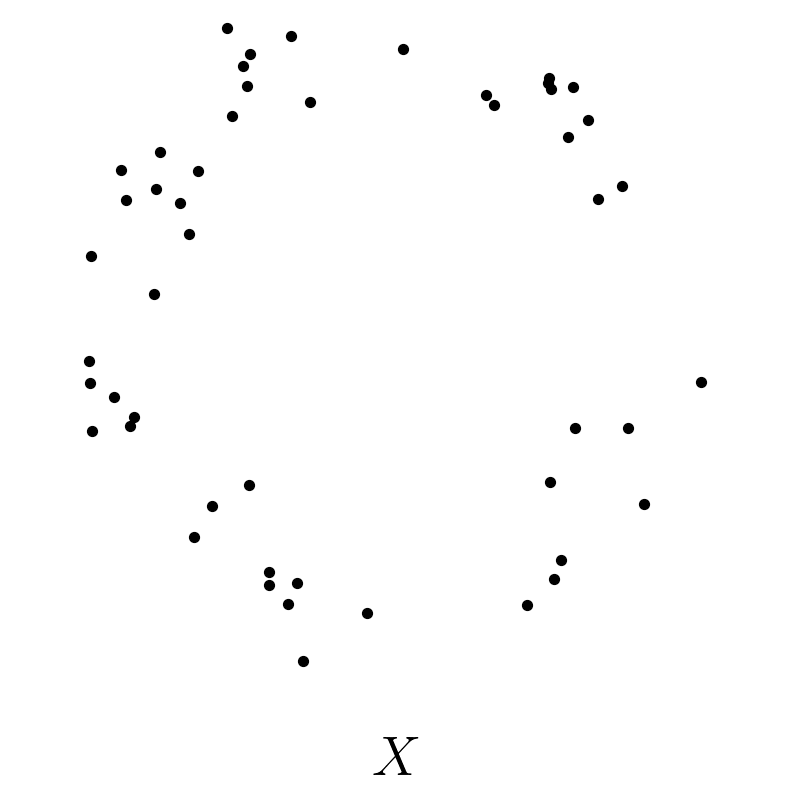

In [27]:
def SampleOnCircle(N = 100, sd = 0):

    '''

    Sample N_observation points from the uniform distribution on the unit circle

    in R^2, with Gaussian noise of standard deviation sd.

       

    Input:

        N (int): number of sample points on the circle.

        N_noise (float, optional): standard deviation of the Gaussian noise

   

    Output :

        data (np.array): size Nx2, the points concatenated.

    '''

    rand_uniform = np.random.rand(N)*2-1    

    X = np.cos(2*np.pi*rand_uniform)

    Y = np.sin(2*np.pi*rand_uniform)

    data = np.stack((X,Y)).transpose() + np.random.normal(0, sd,  (N, 2))

    return data


def BettiNumbers(st, verbose = 'True'):

    '''

    Print the Betti numbers of the simplicial complex 'st'.

   

    Input:

        st: a gudhi.SimplexTree

       

    Example:

        st = gudhi.SimplexTree()

        st.insert([0])

        st.insert([1])

        BettiNumbers(st)

    '''    

    if st.dimension()==0:

        betti_numbers = [st.num_simplices()]

    else:

        st.compute_persistence()

        betti_numbers = st.betti_numbers()

    if verbose:

        print('The Betti numbers are:')

        for i in range(len(betti_numbers)):

            print('Beta_'+repr(i)+' = '+repr(betti_numbers[i]))

    return betti_numbers


def PlotThickening(X,t):

    '''

    Plot a matplotlib figure representing the t-thickening of the point cloud X.

    X must be a point cloud in the plane.

   

    Input:

        X (np.array): size Nx2, the points concatenated.

       

    Example:

        X = np.asarray([[0,1],[1,0],[-1,1]])

        PlotThickening(X, 0.2)

    '''

    if np.shape(X)[1]!=2:

        print('Error! X is not in R^2')

        return False

    N=np.shape(X)[0]

    fig = plt.figure(figsize=(8,8)); ax = fig.add_subplot()

    for i in range(N):

        circle = plt.Circle((X[i,0], X[i,1]), t, color='magenta', alpha = 0.3)

        ax.add_artist(circle)

    for i in range(N):

        point = plt.Circle((X[i,0], X[i,1]), 0.02, facecolor='black', edgecolor = 'black', alpha = 1)

        ax.add_artist(point)

    bound = np.max(np.abs(X))+t    

    plt.xlim(-bound, bound); plt.ylim(-bound, bound)

    plt.axis('off')

    plt.show()


def GetBettiCurvesFromPointCloud(X, J, dim=3):

    '''

    Computes the Betti curves of the Rips complex on the point cloud X,

    on the interval J, up to dimension dim.



    Input:

        X (np.array): size Nx2, the point cloud.

        J (np.array): interval. Shape 1xM.

        dim (int, optional): maximal dimension to compute the Betti curves.

   

    Output:

        BettiCurves (np.array): the Betti curves. Shape (dim+1)xM. The ith

                                Betti curve is given by BettiCurve[i,:].  

                               

    Example:

        X = np.asarray([[0,1],[1,0],[-1,1]])

        J = np.linspace(0,1,100)

        GetBettiCurvesFromPointCloud(X, J, dim = 2)

    '''

    I = 2*J

    tmax = max(I)

    rips = gudhi.RipsComplex(points=X, max_edge_length = tmax)

    st = rips.create_simplex_tree(max_dimension=dim)

    st.persistence(persistence_dim_max=True, homology_coeff_field = 2)

    Diagrams = [st.persistence_intervals_in_dimension(i) for i in range(dim+1)]

    BettiCurves = []

    step_x = I[1]-I[0]

    for diagram in Diagrams:

        bc =  np.zeros(len(I))

        if diagram.size != 0:

            diagram_int = np.clip(np.ceil((diagram[:,:2] - I[0]) / step_x), 0, len(I)).astype(int)

            for interval in diagram_int:

                bc[interval[0]:interval[1]] += 1

        BettiCurves.append(np.reshape(bc,[1,-1]))

    return np.reshape(BettiCurves, (dim+1, len(I)))


def GetBettiCurvesFromDistances(D, J, dim=2):

    '''

    Computes the Betti curves of the Rips complex of the distance matrix D,

    on the interval J, up to dimension dim.



    Input:

        D (np.array): size NxN, the distance matrix.

        J (np.array): interval. Shape 1xM.

        dim (int, optional): maximal dimension to compute the Betti curves.

   

    Output:

        BettiCurves (np.array): the Betti curves. Shape (dim+1)xM. The ith

                                Betti curve is given by BettiCurve[i,:].  



    Example:

        D = np.asarray([[0,1,2],[1,0,3],[2,3,0]])

        J = np.linspace(0,1,100)

        GetBettiCurvesFromDistances(D, J, dim = 1)

    '''

    I = 2*J

    tmax = max(I)

    rips = gudhi.RipsComplex(distance_matrix = D, max_edge_length = tmax)

    st = rips.create_simplex_tree(max_dimension=dim)

    st.persistence(persistence_dim_max=True, homology_coeff_field = 2)

    Diagrams = [st.persistence_intervals_in_dimension(i) for i in range(dim+1)]

    BettiCurves = []

    step_x = I[1]-I[0]

    for diagram in Diagrams:

        bc =  np.zeros(len(I))

        if diagram.size != 0:

            diagram_int = np.clip(np.ceil((diagram[:,:2] - I[0]) / step_x), 0, len(I)).astype(int)

            for interval in diagram_int:

                bc[interval[0]:interval[1]] += 1

        BettiCurves.append(np.reshape(bc,[1,-1]))

    return np.reshape(BettiCurves, (dim+1, len(I)))


def plot_diagram(st, ax, title):

    persistence = st.persistence(homology_coeff_field=2)

    gudhi.plot_persistence_diagram(persistence, axes=ax)

    ax.set_title(title)


N = 50 # number of points
sd = 0.1 # standard deviation of the noise
t = 0.2
X = SampleOnCircle(N, sd)
# plotting the point cloud
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"]
})

# 1. Criando a figura e desenhando os pontos
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(1, 1, 1)
plt.scatter(X[:,0], X[:,1], c='black', s=50)
plt.axis('equal')
plt.axis('off')

# 2. Configurando o título para ficar EMBAIXO da imagem
# y=-0.1 empurra para baixo do eixo horizontal
# pad=-20 ajuda no ajuste fino para não cortar a letra
plt.title(r"$X$", y=-0.1, pad=-20, fontsize=40)

# 3. Ajustando margens e exibindo o gráfico (SEMPRE POR ÚLTIMO)
plt.tight_layout()
plt.show()

# --- Seu processamento com o GUDHI continua aqui embaixo ---
st = gudhi.SimplexTree()
for i in range(N):
    st.insert([i])
for i in range(N):
    for j in range(i):
        if np.linalg.norm(X[i,:]-X[j,:])<=2*t:
            st.insert([i,j])
st.expansion(2)


In [28]:
BettiNumbers(st)

The Betti numbers are:
Beta_0 = 3
Beta_1 = 0


[3, 0]

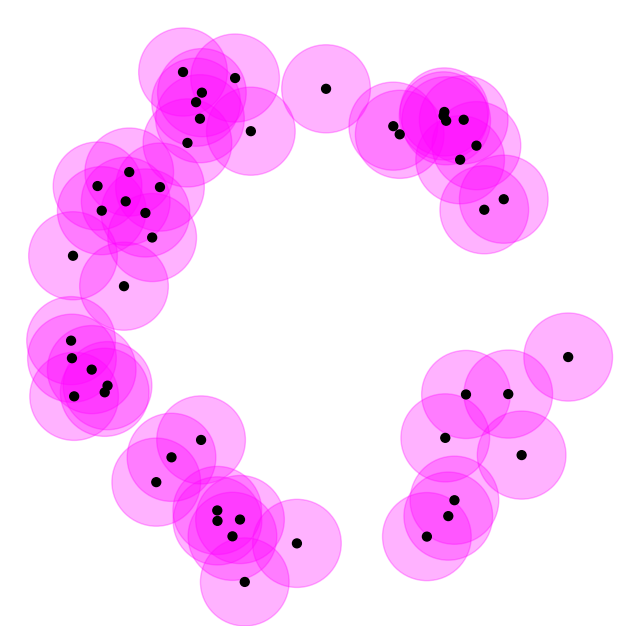

In [29]:
PlotThickening(X, 0.2)

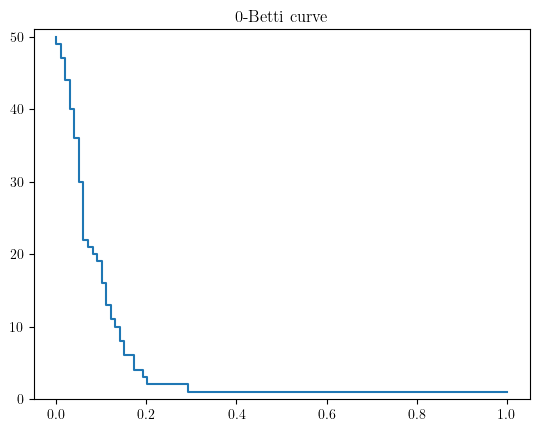

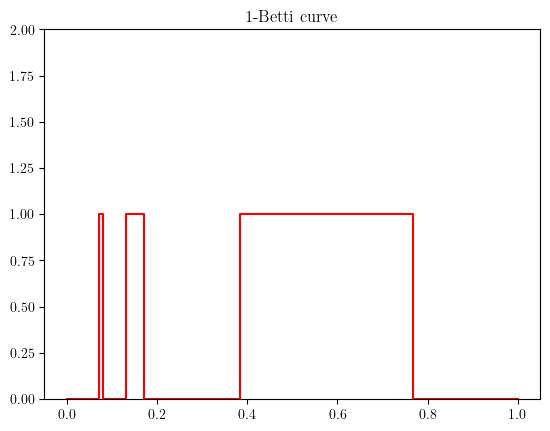

In [31]:
I = np.linspace(0,1,100)
Betti_curves = GetBettiCurvesFromPointCloud(X, I)
plt.figure()
plt.step(I, Betti_curves[0])
plt.ylim(0, max(Betti_curves[0])+1)
plt.title('0-Betti curve')
plt.show()
plt.figure()
plt.step(I, Betti_curves[1], color = "red")
plt.ylim(0, max(Betti_curves[1])+1)
plt.title('1-Betti curve')
plt.show()

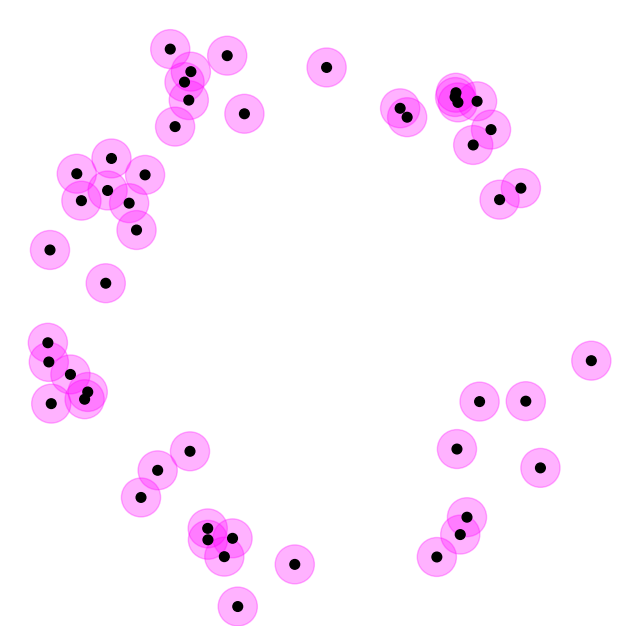

In [32]:
t_noise = I[np.where(Betti_curves[1]>0)][0]
# first appartition of topological noise
PlotThickening(X,t=t_noise)


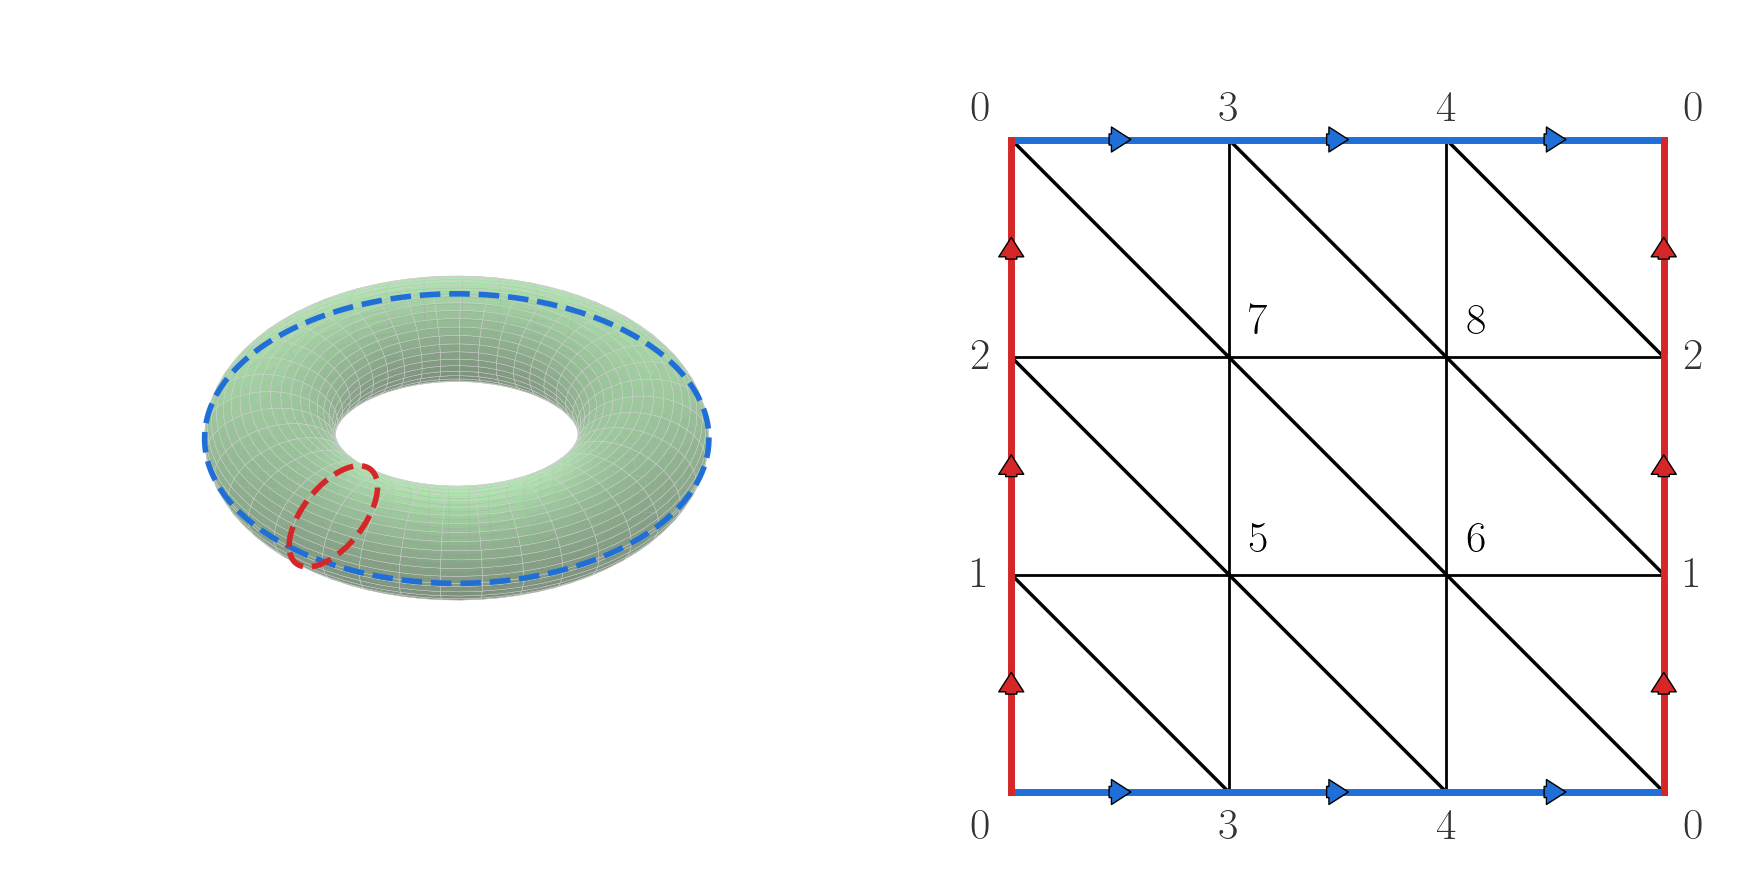

In [72]:
def plot_triangulacao_toro():
    fig = plt.figure(figsize=(18, 9))

    # --- estilo geral ---
    cor_toro   = "lightgreen"
    cor_a      = "#1f6fd6"   # aresta/corte "a" (horizontal no quadrado <-> corte transversal)
    cor_b      = "#d62728"   # aresta/corte "b" (vertical no quadrado   <-> corte sagital)
    cor_diag   = "black"     # diagonais da triangulação interna
    grosso_linha   = 5
    tamanho_fonte  = 32

    # =====================================================================
    # PAINEL 1: Toro 3D com os dois cortes de identificação
    # =====================================================================
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')

    R, r = 2.0, 0.7  # R = raio maior, r = raio do tubo

    # malha suave do toro (parametrização padrão u = volta grande, v = volta do tubo)
    u = np.linspace(0, 2 * np.pi, 80)
    v = np.linspace(0, 2 * np.pi, 80)
    U, V = np.meshgrid(u, v)
    X = (R + r * np.cos(V)) * np.cos(U)
    Y = (R + r * np.cos(V)) * np.sin(U)
    Z = r * np.sin(V)
    ax1.plot_surface(X, Y, Z, color=cor_toro, edgecolor='lightgray',
                      linewidth=0.3, alpha=0.4, zorder=1)

    t = np.linspace(0, 2 * np.pi, 200)

    # --- Corte "a" (transversal): varia u, v fixo (z=0) -> dá a volta grande.
    # Cortar aqui = cortar a aresta 'a' (topo/base do quadrado) -> abre o toro em CILINDRO
    raio_a = R + r
    ax1.plot(raio_a * np.cos(t), raio_a * np.sin(t), np.zeros_like(t),
              color=cor_a, linestyle='--', linewidth=4, zorder=5, label="corte a (transversal)")

    # --- Corte "b" (sagital): varia v, u fixo em 0 -> abraça o tubo.
    # Cortar aqui = cortar a aresta 'b' (laterais do quadrado) -> abre o CILINDRO em RETÂNGULO
    ax1.plot((R + r * np.cos(t)) * np.cos(0), (R + r * np.cos(t)) * np.sin(0), r * np.sin(t),
              color=cor_b, linestyle='--', linewidth=4, zorder=5, label="corte b (sagital)")

    ax1.set_xlim(-3, 3); ax1.set_ylim(-3, 3); ax1.set_zlim(-3, 3)
    ax1.view_init(elev=35, azim=40)
    ax1.axis('off')

    # =====================================================================
    # PAINEL 2: quadrado de identificação + triangulação (3x3 = 18 triângulos)
    # =====================================================================
    ax2 = fig.add_subplot(1, 2, 2)

    # matriz de rótulos fornecida (linha 0 = topo, y=3 ... linha 3 = base, y=0)
    matriz_vertices = [
        ['0', '3', '4', '0'],
        ['2', '7', '8', '2'],
        ['1', '5', '6', '1'],
        ['0', '3', '4', '0'],
    ]

    # --- malha interna 4x4: horizontais e verticais em preto/cinza fino ---
    for i in range(4):
        ax2.plot([0, 3], [i, i], color="black", linewidth=2, zorder=1)
        ax2.plot([i, i], [0, 3], color="black", linewidth=2, zorder=1)

    # --- diagonais principais dos 9 sub-quadrados (triangulação) ---
    for x in range(3):
        for y in range(3):
            ax2.plot([x, x + 1], [y + 1, y], color=cor_diag, linewidth=2.5, zorder=2)

    # --- bordas de identificação destacadas: 'a' = topo/base (azul), 'b' = laterais (vermelho) ---
    ax2.plot([0, 3], [0, 0], color=cor_a, linewidth=grosso_linha, zorder=3)
    ax2.plot([0, 3], [3, 3], color=cor_a, linewidth=grosso_linha, zorder=3)
    ax2.plot([0, 0], [0, 3], color=cor_b, linewidth=grosso_linha, zorder=3)
    ax2.plot([3, 3], [0, 3], color=cor_b, linewidth=grosso_linha, zorder=3)

    # --- setas de orientação (mesmo sentido nas duas bordas = identificação de toro, não Klein) ---
    seta_kw = dict(arrowprops=dict(width=8, headwidth=18, headlength=14, shrink=0.4))
    for pos in [0.5, 1.5, 2.5]:
        ax2.annotate("", xy=(pos + 0.25, 0), xytext=(pos - 0.25, 0), zorder=4,
                     **{**seta_kw, 'arrowprops': {**seta_kw['arrowprops'], 'facecolor': cor_a}})
        ax2.annotate("", xy=(pos + 0.25, 3), xytext=(pos - 0.25, 3), zorder=4,
                     **{**seta_kw, 'arrowprops': {**seta_kw['arrowprops'], 'facecolor': cor_a}})
        ax2.annotate("", xy=(0, pos + 0.25), xytext=(0, pos - 0.25), zorder=4,
                     **{**seta_kw, 'arrowprops': {**seta_kw['arrowprops'], 'facecolor': cor_b}})
        ax2.annotate("", xy=(3, pos + 0.25), xytext=(3, pos - 0.25), zorder=4,
                     **{**seta_kw, 'arrowprops': {**seta_kw['arrowprops'], 'facecolor': cor_b}})

    # --- rótulos dos vértices (offset pra não colidir com as linhas) ---
    for x_idx in range(4):
        for y_idx in range(4):
            valor = matriz_vertices[3 - y_idx][x_idx]  # inverte linha p/ y crescer pra cima
            if valor in ['5', '6', '7', '8']:            # vértices internos
                off_x, off_y = 0.14, 0.16
            else:                                          # vértices de borda (identificados)
                off_x = -0.14 if x_idx == 0 else (0.14 if x_idx == 3 else 0.0)
                off_y = -0.16 if y_idx == 0 else (0.14 if y_idx == 3 else 0.0)
            cor_txt = cor_diag if valor in ['5', '6', '7', '8'] else "#333333"
            bbox = dict(boxstyle="circle,pad=0.15", fc="white", ec="none", alpha=0.85)
            ax2.text(x_idx + off_x, y_idx + off_y, valor, fontsize=tamanho_fonte,
                      fontweight='bold', color=cor_txt, ha='center', va='center',
                      zorder=6, bbox=bbox)

    ax2.set_xlim(-0.4, 3.4)
    ax2.set_ylim(-0.4, 3.6)
    ax2.set_aspect('equal')
    ax2.axis('off')
    plt.tight_layout()
    plt.show()

plot_triangulacao_toro()

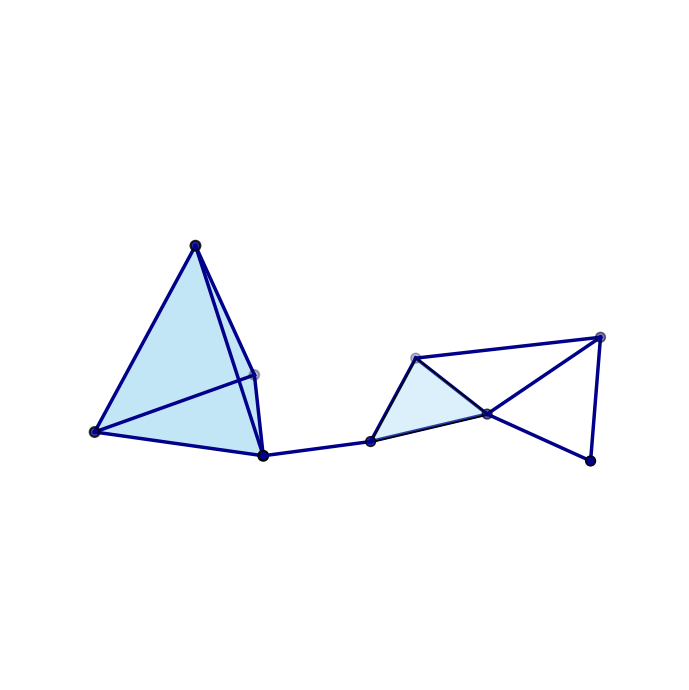

In [149]:
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_complexo_betti_customizado():
    fig = plt.figure(figsize=(14, 7))
    ax = fig.add_subplot(1, 1, 1, projection='3d')
    
    # Estilos e paleta de cores padrão
    cor_face = (0.54, 0.81, 0.94, 0.3) # Azul translúcido padrão
    cor_borda = 'darkblue'
    grosso_linha = 2.5
    grosso_vertice = 50

    # =========================================================================
    # COMPONENTE A: O Tetraedro Oco (Garante: +1 Componente Conexa, +1 Cavidade 3D)
    # =========================================================================
    # Coordenadas dos 4 vértices deslocadas para a esquerda no eixo X
    v_tetra = np.array([
        [-2.0,  0.0,  1.2],  # Topo (0)
        [-2.8, -0.6, -0.5],  # Base Esquerda (1)
        [-0.8, -0.5, -0.5],  # Base Direita (2)
        [-2.0,  0.9, -0.5]   # Base Profundidade (3)
    ])
    
    # As 6 arestas estruturais do tetraedro
    arestas_tetra = [(0, 1), (0, 2), (0, 3), (1, 2), (2, 3), (3, 1)]
    for edge in arestas_tetra:
        ax.plot([v_tetra[edge[0], 0], v_tetra[edge[1], 0]],
                [v_tetra[edge[0], 1], v_tetra[edge[1], 1]],
                [v_tetra[edge[0], 2], v_tetra[edge[1], 2]],
                color=cor_borda, linewidth=grosso_linha, zorder=3)
        
    # As 4 faces externas que fecham a casca (Oco por dentro para beta_2 = 1)
    faces_tetra = [
        [v_tetra[0], v_tetra[1], v_tetra[2]],
        [v_tetra[0], v_tetra[2], v_tetra[3]],
        [v_tetra[0], v_tetra[3], v_tetra[1]],
        [v_tetra[1], v_tetra[2], v_tetra[3]]
    ]
    ax.add_collection3d(Poly3DCollection(faces_tetra, facecolors=cor_face, edgecolors='black', zorder=2))
    
    # Desenha os vértices do componente A
    ax.scatter(v_tetra[:, 0], v_tetra[:, 1], v_tetra[:, 2], color=cor_borda, s=grosso_vertice, zorder=4, edgecolors="black", linewidths=1.5)

    # =========================================================================
    # COMPONENTE B: Grafo de Triângulos Ocos (Garante: +1 Componente Conexa, +3 Laços)
    # =========================================================================
    # Estrutura com 5 vértices que formam 3 ciclos/buracos independentes e adjacentes
    # Todos os vértices estão contidos no plano Z = 0 e deslocados para a direita no eixo X
    v_laços = np.array([
        [1.5,  0.0, 0.0],  # Centro divisor (0)
        [0.1,  0.8, 0.0],  # Superior Esquerdo (1)
        [2.3,  0.8, 0.5],  # Superior Direito (2)
        [0.7, -0.8, 0.0],  # Inferior Esquerdo (3)
        [3, -0.5, 0.0]   # Inferior Direito (4)
    ])
    
    # Conexões geradoras de 3 buracos vazados independentes (Ex: 0-1-2-0, 0-1-3-0, 0-2-4-0)
    arestas_laços = [
        (0, 1), (1, 2), (2, 0),  # Buraco 1 (Triângulo de Cima)
        (1, 3), (3, 0),          # Buraco 2 (Triângulo Lateral Esquerdo)
        (2, 4), (4, 0),          # Buraco 3 (Triângulo Lateral Direito)
        # (3, 4)                   # Fecha a base externa inferior
    ]
    
    for edge in arestas_laços:
        ax.plot([v_laços[edge[0], 0], v_laços[edge[1], 0]],
                [v_laços[edge[0], 1], v_laços[edge[1], 1]],
                [v_laços[edge[0], 2], v_laços[edge[1], 2]],
                color=cor_borda, linewidth=grosso_linha, zorder=3)
    
    face_triangulo_preenchido = [[v_laços[0], v_laços[1], v_laços[3]]]
    ax.add_collection3d(Poly3DCollection(face_triangulo_preenchido, facecolors=cor_face, edgecolors='black', zorder=2))

    # Desenha os vértices do componente B
    ax.scatter(v_laços[:, 0], v_laços[:, 1], v_laços[:, 2], color=cor_borda, s=grosso_vertice, zorder=4, edgecolors="black")

    ax.plot([v_laços[3, 0], v_tetra[2, 0]],
            [v_laços[3, 1], v_tetra[2, 1]],
            [v_laços[3, 2], v_tetra[2, 2]],
            color=cor_borda, linewidth=grosso_linha, linestyle='-', zorder=4)
    
    # =========================================================================
    # Configurações do Ambiente e Legenda Inferior de Assinatura Topológica
    # =========================================================================
    ax.set_xlim(-2.5, 2.2)
    ax.set_ylim(-1.4, 1.6)
    ax.set_zlim(-1.0, 2.0)
    
    # Ângulo de visualização em perspectiva tridimensional limpa
    ax.view_init(elev=20, azim=-65)
    ax.axis('off')
    
    # Título acadêmico posicionado de forma fixa embaixo
    legenda_betti = r"Complexo Simplicial Concretizado: $\beta_0 = 2, \quad \beta_1 = 3, \quad \beta_2 = 1$"
    # ax.set_title(legenda_betti, y=-0.05, fontsize=24, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Executa o plot da topologia customizada
plot_complexo_betti_customizado()

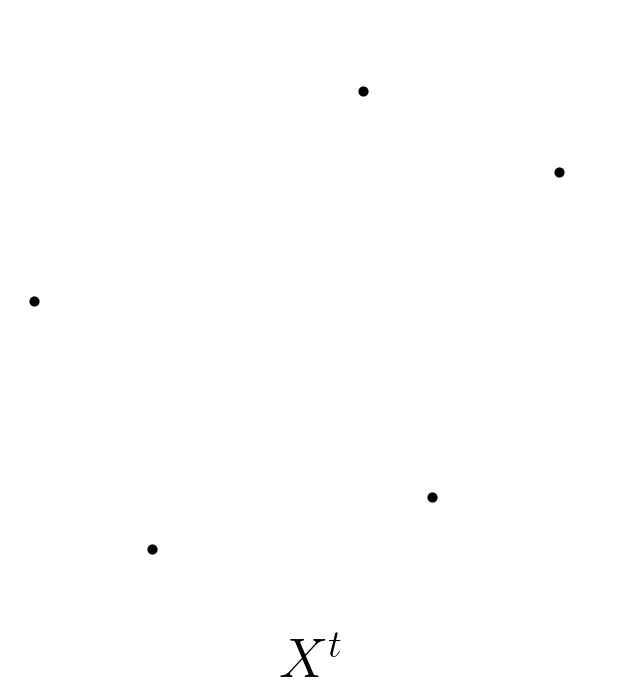

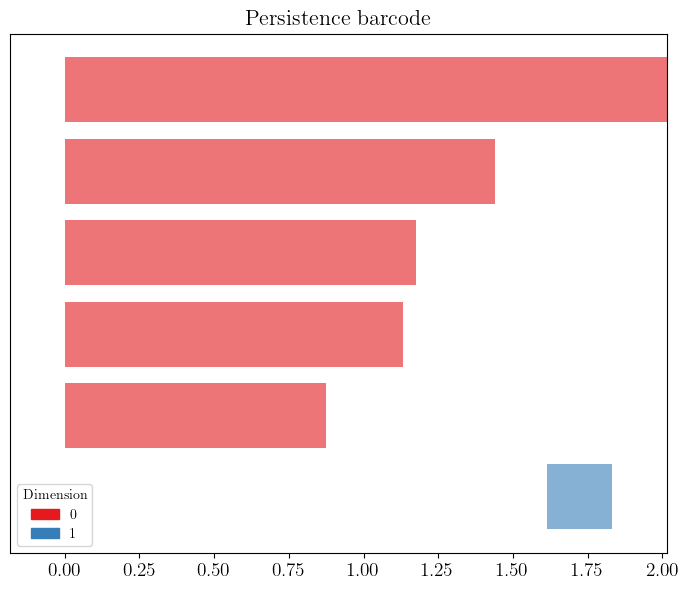

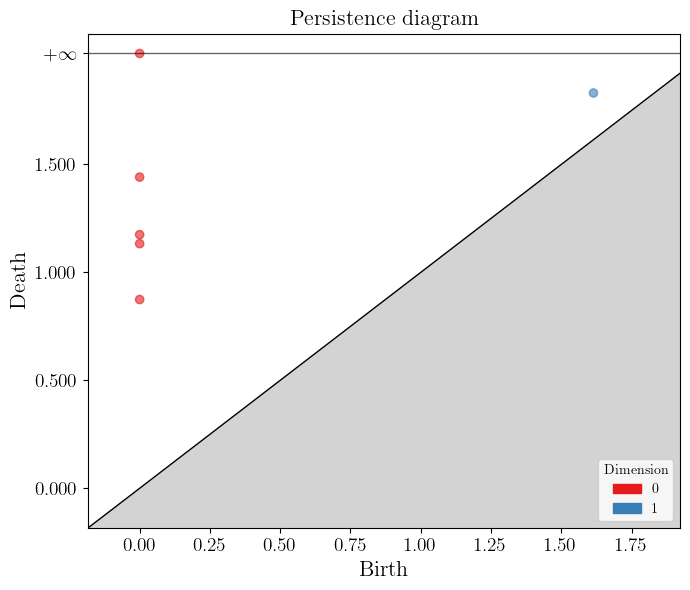

In [36]:
def SampleOnCircle(N = 100, sd = 0):
    rand_uniform = np.random.rand(N)*2-1    

    X = np.cos(2*np.pi*rand_uniform)

    Y = np.sin(2*np.pi*rand_uniform)

    data = np.stack((X,Y)).transpose() + np.random.normal(0, sd,  (N, 2))

    return data

def calcular_persistencia(X, max_edge_length=2.0, max_dimension=2, homology_coeff_field=2):
    """Monta o complexo de Rips e retorna a persistência (chamado 1x, sem estado global)."""
    rips = gudhi.RipsComplex(points=X, max_edge_length=max_edge_length)
    st = rips.create_simplex_tree(max_dimension=max_dimension)
    return st.persistence(homology_coeff_field=homology_coeff_field)
 
 
def plot_thickening(X, t=0.2, figsize=(7, 7), save_path=None, dpi=300):
    """
    Desenha X^t: bolas de raio t (magenta), arestas de Rips (dist <= 2t) e os pontos.
    Distâncias e desenho são vetorizados: sem loop duplo, sem 1 ax.plot por aresta.
    """
    fig, ax = plt.subplots(figsize=figsize)
 
    # 1. bolas translúcidas — todas num único PatchCollection
    bolas = PatchCollection([Circle((xi, yi), t) for xi, yi in X],
                             color='magenta', alpha=0.15, zorder=1)
    ax.add_collection(bolas)
 
    # 2. arestas de Rips — distância par-a-par calculada de uma vez (pdist),
    #    pares dentro do raio 2t viram um único LineCollection
    D = squareform(pdist(X))
    i_idx, j_idx = np.where(np.triu(D <= 2 * t, k=1))  # só pares únicos i<j
    segmentos = np.stack([X[i_idx], X[j_idx]], axis=1)
    ax.add_collection(LineCollection(segmentos, colors='black', linewidths=1,
                                      alpha=0.4, zorder=2))
 
    # 3. 0-símplices (pontos)
    ax.scatter(X[:, 0], X[:, 1], c='black', s=40, zorder=3)
 
    # bordas com folga pro raio das bolas não cortar na moldura
    bound = np.max(np.abs(X)) + t + 0.1
    ax.set_xlim(-bound, bound)
    ax.set_ylim(-bound, bound)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(r"$X^t$", y=-0.12, fontsize=40, fontweight='bold')
 
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')
    plt.show()
    return fig, ax
 
 
def plot_persistencia(persistence, kind='diagram', figsize=(7, 6), save_path=None, dpi=300):
    """Diagrama ou barcode de persistência (kind='diagram' | 'barcode'), sem código duplicado."""
    plot_fn = {'diagram': gudhi.plot_persistence_diagram,
               'barcode': gudhi.plot_persistence_barcode}[kind]
 
    fig, ax = plt.subplots(figsize=figsize)
    plot_fn(persistence, axes=ax)
    ax.tick_params(axis='both', labelsize=14)
 
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')
    plt.show()
    return fig, ax
 
 
if __name__ == "__main__":
    # Exemplo de uso — troque X pela sua nuvem de pontos real
    # rng = np.random.default_rng(2)
    # X = rng.normal(size=(7, 2))
    X = SampleOnCircle(5, sd=0.1)
    persistence = calcular_persistencia(X, max_edge_length=2.0)
 
    plot_thickening(X, t=0)                          # save_path='thickening.pdf'
    plot_persistencia(persistence, kind='barcode')      # save_path='barcode.pdf'
    plot_persistencia(persistence, kind='diagram')      # save_path='diagrama.pdf'
 

In [113]:
def atualizar_plot_thickening(valor_slider):
    X_plot = X  # Usa os seus pontos preservados
    N = X_plot.shape[0]
    D = squareform(pdist(X_plot))
    t = valor_slider / 2.0  # O raio visual é metade do parâmetro do Rips
    
    fig, ax = plt.subplots(figsize=(7, 7))
    
    # 1. Bolas translúcidas (t-espessamento)
    bolas = PatchCollection([Circle((xi, yi), t) for xi, yi in X_plot],
                            color=(0.54, 0.81, 0.94, 0.45), zorder=1)
    ax.add_collection(bolas)
    
    # 2. Triângulos (2-símplices) - Clique K_3 vetorizado
    triangulos_lista = []
    for i in range(N):
        vizinhos = np.where((D[i] <= valor_slider))[0]
        vizinhos = vizinhos[vizinhos > i]
        for idx_v1, j in enumerate(vizinhos):
            for k in vizinhos[idx_v1 + 1:]:
                if D[j, k] <= valor_slider:
                    triangulos_lista.append(Polygon([X_plot[i], X_plot[j], X_plot[k]], closed=True))
                    
    coll_triangulos = PatchCollection(triangulos_lista, facecolor='darkblue', alpha=0.25, edgecolor='none', zorder=2)
    ax.add_collection(coll_triangulos)
    
    # 3. Arestas de Rips (1-símplices)
    i_idx, j_idx = np.where(np.triu(D <= valor_slider, k=1))
    segmentos = np.stack([X_plot[i_idx], X_plot[j_idx]], axis=1)
    ax.add_collection(LineCollection(segmentos, colors='black', linewidths=1, alpha=0.4, zorder=3))
    
    # 4. Vértices (0-símplices)
    ax.scatter(X_plot[:, 0], X_plot[:, 1], c='black', s=40, zorder=4)
    
    # Ajustes estéticos fixos para as esferas não cortarem nas bordas
    bound = np.max(np.abs(X_plot)) + 1
    ax.set_xlim(-bound, bound)
    ax.set_ylim(-bound, bound)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # ax.set_title(rf"$X^{{t}}$ (Filtra\c{{c}}\~ao $= {valor_slider:.2f}$, $t = {t:.2f}$)", y=-0.12, fontsize=24, fontweight='bold')
    plt.show()

widgets.interact(
    atualizar_plot_thickening,
    valor_slider=widgets.FloatSlider(value=0.0, min=0.00, max=2.0, step=0.01, layout=widgets.Layout(width='60%')))

interactive(children=(FloatSlider(value=0.0, description='valor_slider', layout=Layout(width='60%'), max=2.0, …

<function __main__.atualizar_plot_thickening(valor_slider)>

4


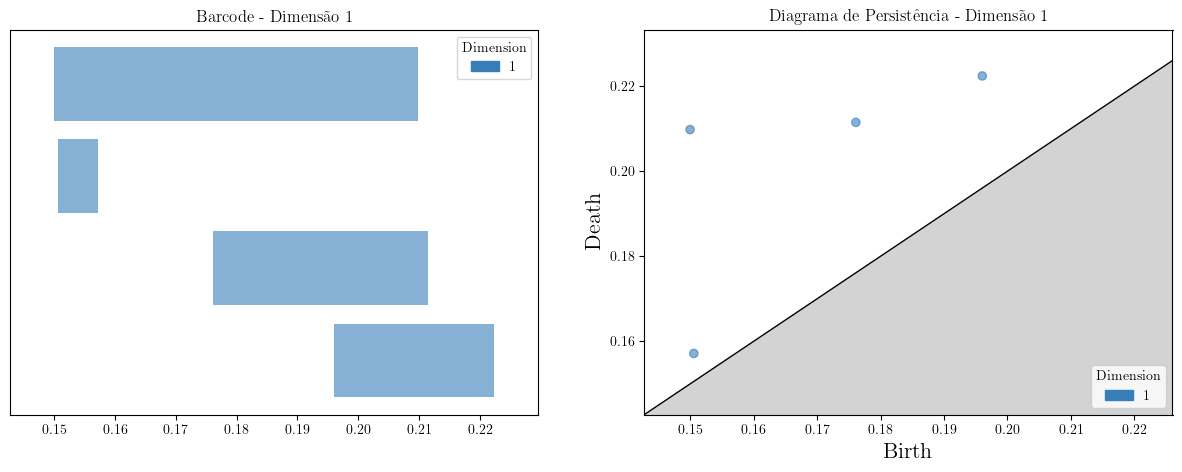

11


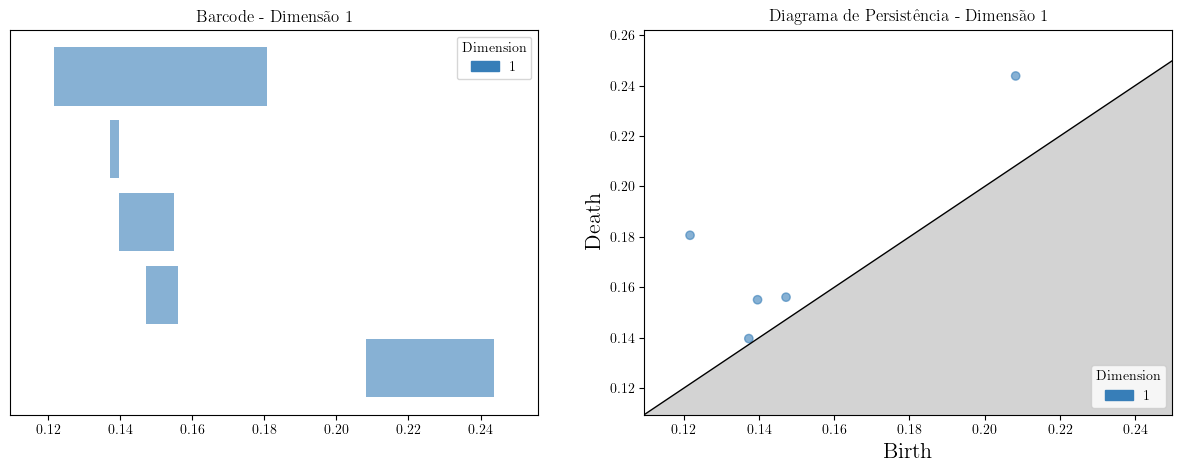

29


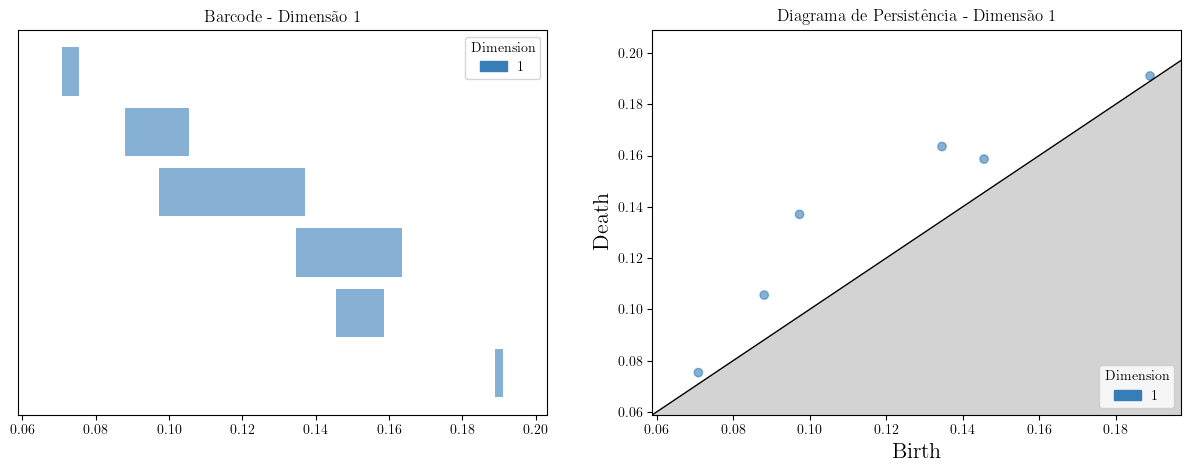

45


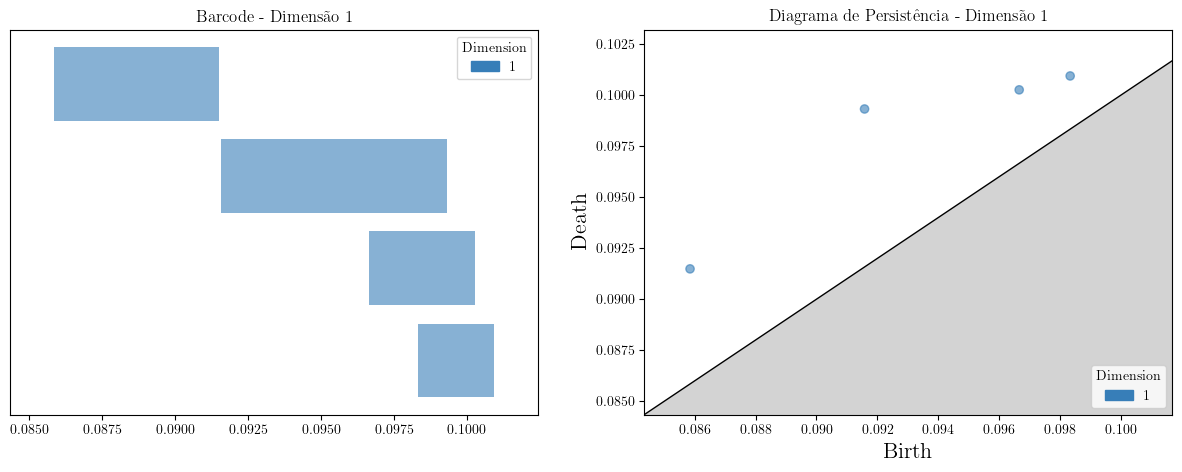

51


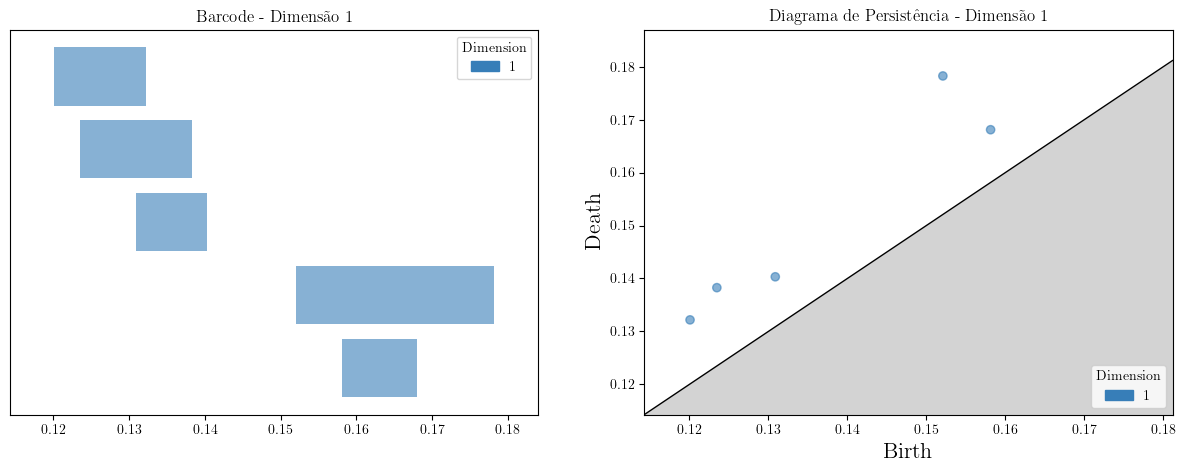

60


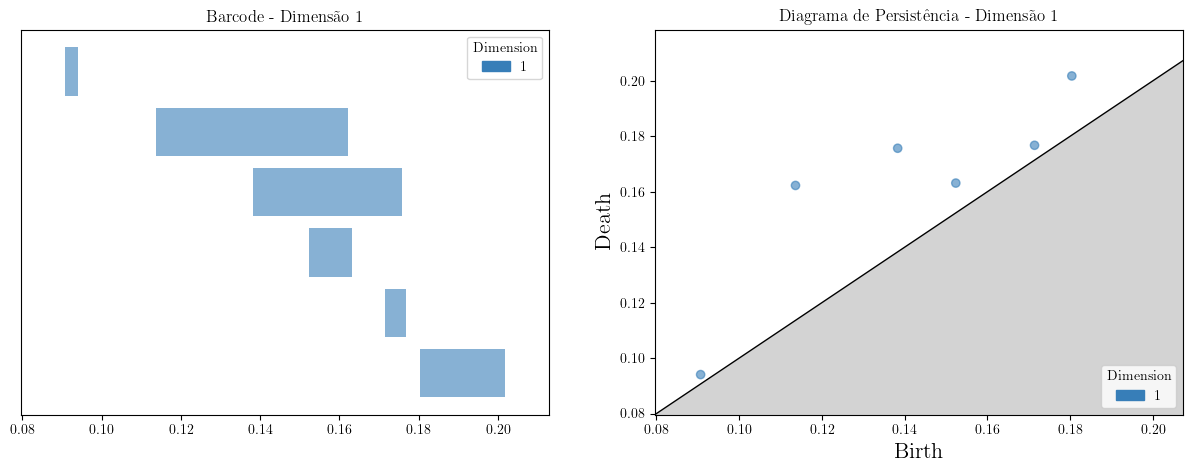

In [47]:
for i in [4, 11, 29, 45, 51, 60]:
    np.random.seed(i) 
    X = np.random.rand(25, 2)
    t = 1

    # O parâmetro do Rips (distância máxima para conectar) é o diâmetro (2 * t)
    diametro_max = 2 * t

    # =========================================================================
    # 2. CONSTRUÇÃO MATEMÁTICA DO COMPLEXO (GUDHI)
    # =========================================================================
    rips = gudhi.RipsComplex(points=X/2, max_edge_length=diametro_max)
    st = rips.create_simplex_tree(max_dimension=2)
    barcodes = st.persistence(homology_coeff_field=2)

    # =========================================================================
    # O SEGREDO ESTÁ AQUI: Filtramos a lista para pegar apenas a dimensão 1
    # =========================================================================
    barcodes_dim1 = [intervalo for intervalo in barcodes if intervalo[0] == 1]

    # Configurando a figura
    fig = plt.figure(figsize=(15,5))
    ax1 = fig.add_subplot(1,2,1) 
    ax2 = fig.add_subplot(1,2,2)

    # Passando a lista já filtrada para as funções do gudhi
    gudhi.plot_persistence_barcode(persistence=barcodes_dim1, axes=ax1)
    ax1.set_title("Barcode - Dimensão 1")

    gudhi.plot_persistence_diagram(persistence=barcodes_dim1, axes=ax2)
    ax2.set_title("Diagrama de Persistência - Dimensão 1")
    print(i)
    plt.show()



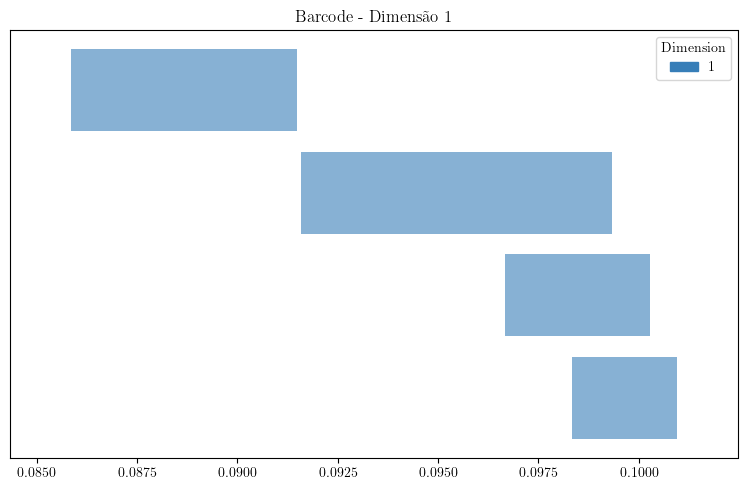

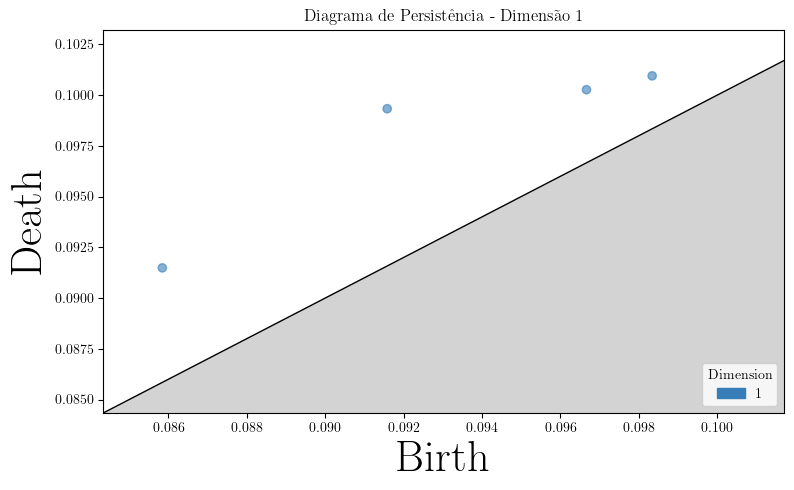

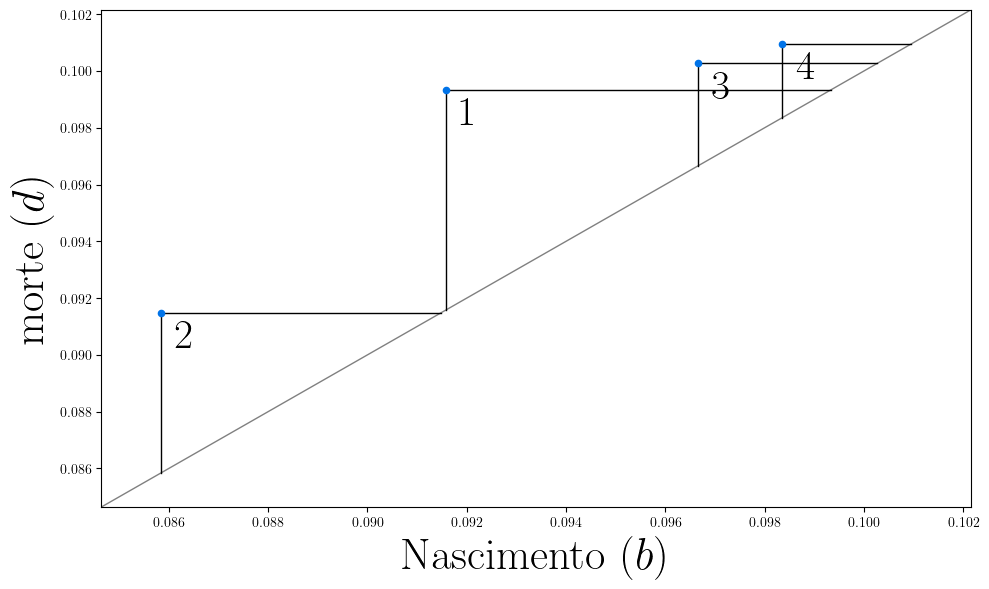

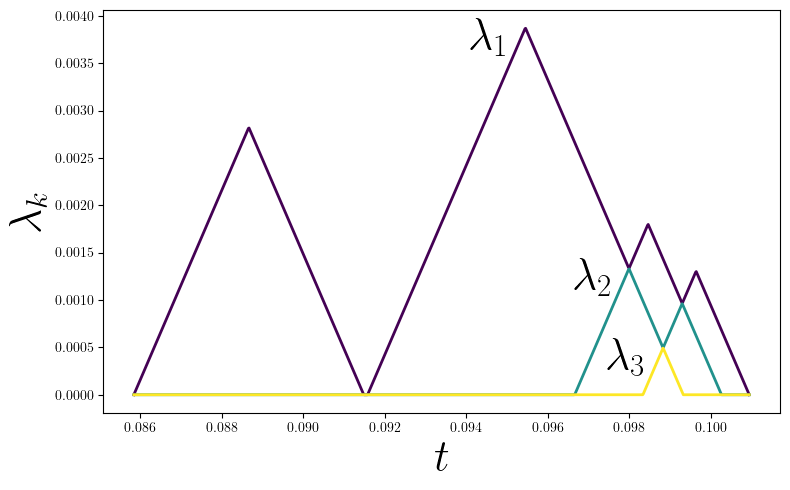

In [143]:
# ETAPA 1: diagrama de persistência com os "triângulos" de cada ponto
# =============================================================================
def plot_diagrama_triangulado(pontos_bd, ax=None):
    """
    pontos_bd: lista de (b, d) finitos, já ordenada (ordem = numeração 1..n).
    Para cada ponto (b,d): vertical em x=b indo até a diagonal (nascimento),
    horizontal em y=d indo até a diagonal (morte). O ponto é o vértice do
    ângulo reto; a diagonal é a hipotenusa.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 4))

    b_min = min(b for b, _ in pontos_bd)
    d_max = max(d for _, d in pontos_bd)
    margem = (d_max - b_min) * 0.08          # folga proporcional ao alcance dos dados
    lim_inf = b_min - margem
    lim_sup = d_max + margem
    ax.plot([lim_inf, lim_sup], [lim_inf, lim_sup], color='gray', linewidth=1, zorder=1)

    for n, (b, d) in enumerate(pontos_bd, start=1):
        ax.plot([b, b], [b, d], color="black", linewidth=1, zorder=2)   # vertical -> nascimento
        ax.plot([b, d], [d, d], color='black', linewidth=1, zorder=2)   # horizontal -> morte
        ax.scatter(b, d, color=(0, 0.45, 0.91), s=20, zorder=3)
        ax.annotate(str(n), (b, d), xytext=(10, -25), textcoords='offset points',
                    fontsize=30, fontweight='bold', zorder=4)

    ax.set_xlim(lim_inf, lim_sup); ax.set_ylim(lim_inf, lim_sup)
    ax.set_xlabel(r'Nascimento $(b)$', fontsize=32); ax.set_ylabel(r'morte $(d)$', fontsize = 32)
    # ax.set_aspect('equal')
    # ax.set_title(f'Diagrama triangulado (n = {len(pontos_bd)} pontos)')
    return ax


# =============================================================================
# ETAPA 2: as landscape functions lambda_k(t), calculadas ponto a ponto
# =============================================================================
def calcular_landscapes(pontos_bd, n_grid=1000):
    """
    Cada ponto (b,d) gera uma "tenda" f_i(t) = max(0, min(t-b, d-t)).
    lambda_k(t) = k-esimo maior valor entre todas as tendas, em cada t
    (definicao de Bubenik). Retorna t (grade) e L, shape (K, n_grid),
    ja sem as camadas que sao identicamente zero.
    """
    bs = np.array([b for b, _ in pontos_bd])
    ds = np.array([d for _, d in pontos_bd])
    t = np.linspace(bs.min(), ds.max(), n_grid)

    tendas = np.maximum(0, np.minimum(t[None, :] - bs[:, None], ds[:, None] - t[None, :]))
    L = -np.sort(-tendas, axis=0)          # ordena decrescente coluna a coluna (por t fixo)
    L = L[~np.all(L == 0, axis=1)]         # descarta camadas totalmente nulas
    return t, L


# =============================================================================
# ETAPA 3: landscape 2D, uma cor por camada k
# =============================================================================
def plot_landscapes_2d(t, L, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    cores = plt.cm.viridis(np.linspace(0, 1, len(L)))
    for k, (camada, cor) in enumerate(zip(L, cores), start=1):
        ax.plot(t, camada, color=cor, linewidth=2)
        idx_pico = np.argmax(camada)                         # ponto mais alto da camada
        ax.annotate(rf'$\lambda_{{{k}}}$', xy=(t[idx_pico], camada[idx_pico]),
                    xytext=(-40, -15), textcoords='offset points',
                    color='black', fontsize=32, fontweight='bold')

    ax.set_xlabel(r'$t$', fontsize = 32)
    ax.set_ylabel(r'$\lambda_k$', fontsize = 32)
    # ax.set_title('Persistence landscape em 2D')
    return ax


# =============================================================================
# ETAPA 4: landscape 3D — as camadas como "cordilheira" (t, k, lambda_k(t))
# =============================================================================
def plot_landscapes_3d(t, L, ax=None):
    if ax is None:
        fig = plt.figure(figsize=(12, 8))
        # Limpa o fundo do Jupyter e prepara o eixo 3D
        ax = fig.add_subplot(111, projection='3d')

    T_mesh = []
    Y_mesh = []
    Z_mesh = []

    # Construção da "Malha em Degraus" (Stepped Mesh)
    for k in range(len(L)):
        # Cada montanha ocupará exatamente 1 unidade de espessura no eixo Y (ex: de 1 até 2)
        # Como o fundo da montanha 1 está em Y=2 e a frente da montanha 2 também começa em Y=2,
        # elas ficam 100% coladas, forçando uma parede vertical entre as camadas.
        y_frente = k + 1
        y_fundo = k + 2
        
        # Duplica as coordenadas T (comprimento)
        T_mesh.extend([t, t])
        # Define as paredes da frente e de trás
        Y_mesh.extend([np.full_like(t, y_frente), np.full_like(t, y_fundo)])
        # A altura Z (a montanha) se mantém igual na frente e atrás para formar o teto plano
        Z_mesh.extend([L[k], L[k]])

    # Converte as listas para matrizes 2D que o plot_surface exige
    T_mesh = np.array(T_mesh)
    Y_mesh = np.array(Y_mesh)
    Z_mesh = np.array(Z_mesh)

    # Plota a superfície em degraus contínuos
    # cmap='viridis' aplica o degradê perfeito: base muito escura -> pico muito claro
    ax.plot_surface(T_mesh, Y_mesh, Z_mesh, 
                    cmap='plasma', 
                    edgecolor='black',  # Arestas pretas para manter o visual de blocos/sólido
                    linewidth=0.3, 
                    alpha=0.9,          # Leve transparência para não ficar tão opaco
                    antialiased=True)

    # Configurações de limites e proporções
    ax.set_xlim(t.min(), t.max())
    ax.set_ylim(1, len(L) + 1)
    ax.set_zlim(0, L.max() * 1.05)
    
    # Rótulos (Labels)
    ax.set_xlabel(r'$t$', labelpad=15, fontsize = 25)
    ax.set_ylabel(r'$k$', labelpad=15, fontsize = 25)
    ax.set_zlabel(r'$\lambda_k(t)$', labelpad=10, fontsize=25)
    
    # Ajusta os rótulos do eixo Y para caírem exatamente no meio do "teto" de cada sólido
    ax.set_yticks(np.arange(1.5, len(L) + 1.5))
    # ax.set_yticklabels([rf'$\lambda_{{{k+1}}}$' for k in range(len(L))], fontsize=14)

    # Inverte o eixo Y para a montanha gigante (lambda_1) ficar na frente
    ax.invert_yaxis()
    
    # Ângulo isométrico para visualizar bem a união das montanhas
    ax.view_init(elev=35, azim=-50)
    ax.set_title('Persistence Landscape', fontsize=30, pad=20)

    return ax


# =============================================================================
# DEMONSTRAÇÃO — usando seu código de Rips original, um seed por vez
# =============================================================================
if __name__ == "__main__":
    for i in [45]:   # troque por [4, 11, 29, 45, 51, 60] para rodar todos os seeds
        np.random.seed(i)
        X = np.random.rand(25, 2)
        t_param = 1
        diametro_max = 2 * t_param

        rips = gudhi.RipsComplex(points=X / 2, max_edge_length=diametro_max)
        st = rips.create_simplex_tree(max_dimension=2)
        barcodes = st.persistence(homology_coeff_field=2)

        barcodes_dim1 = [intervalo for intervalo in barcodes if intervalo[0] == 1]

        # só pontos finitos entram no triângulo/landscape; ordenados por persistência decrescente
        pontos_bd = sorted(
            [(b, d) for _, (b, d) in barcodes_dim1 if np.isfinite(d)],
            key=lambda bd: bd[1] - bd[0], reverse=True
        )

        if not pontos_bd:
            continue  # nada pra desenhar nesse seed

        # --- diagrama original (referência) ---
        fig = plt.figure(figsize=(15, 5))
        ax1 = fig.add_subplot(1, 2, 1)
        gudhi.plot_persistence_barcode(persistence=barcodes_dim1, axes=ax1, fontsize=32)
        ax1.set_title("Barcode - Dimensão 1")
        plt.tight_layout()
        plt.show()

        fig = plt.figure(figsize=(15, 5))
        ax2 = fig.add_subplot(1, 2, 2)
        gudhi.plot_persistence_diagram(persistence=barcodes_dim1, axes=ax2, fontsize=32)
        ax2.set_title("Diagrama de Persistência - Dimensão 1")
        plt.tight_layout()
        plt.show()

        # --- diagrama com triângulos enumerados ---
        fig, ax = plt.subplots(figsize=(10, 6))
        plot_diagrama_triangulado(pontos_bd, ax=ax)
        plt.tight_layout()
        plt.show()

        # --- landscape 2D e 3D ---
        t_grid, L = calcular_landscapes(pontos_bd, n_grid=1000)

        fig, ax = plt.subplots(figsize=(8, 5))
        plot_landscapes_2d(t_grid, L, ax=ax)
        plt.tight_layout()
        plt.show()

        # fig = plt.figure(figsize=(9, 7))
        # ax = fig.add_subplot(111, projection='3d')
        # plot_landscapes_3d(t_grid, L, ax=ax)
        # plt.tight_layout()
        # plt.show()

In [125]:
%matplotlib inline


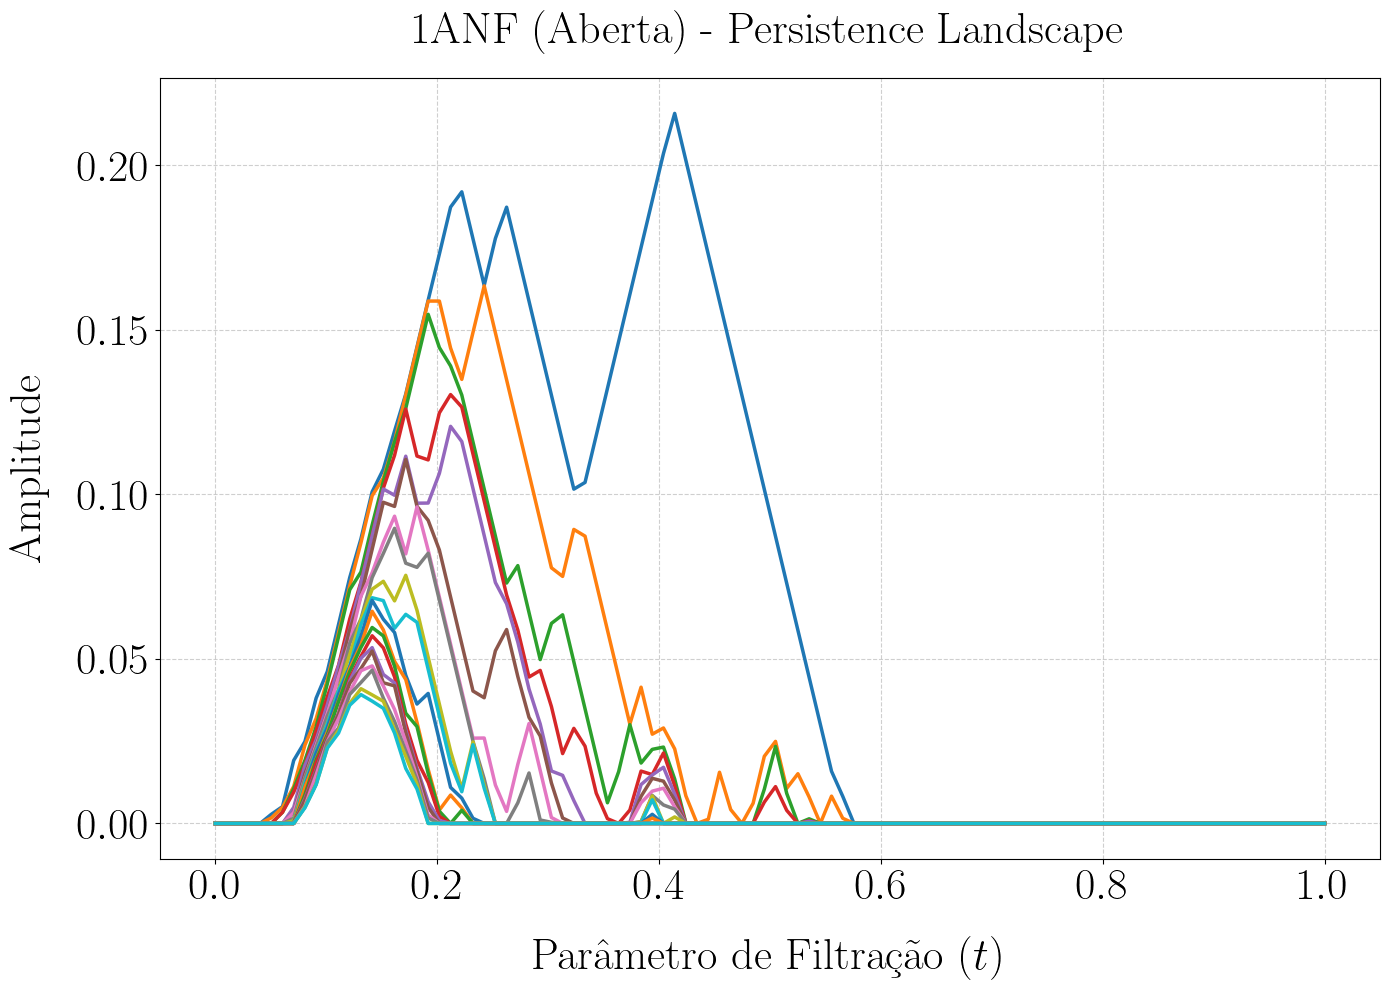

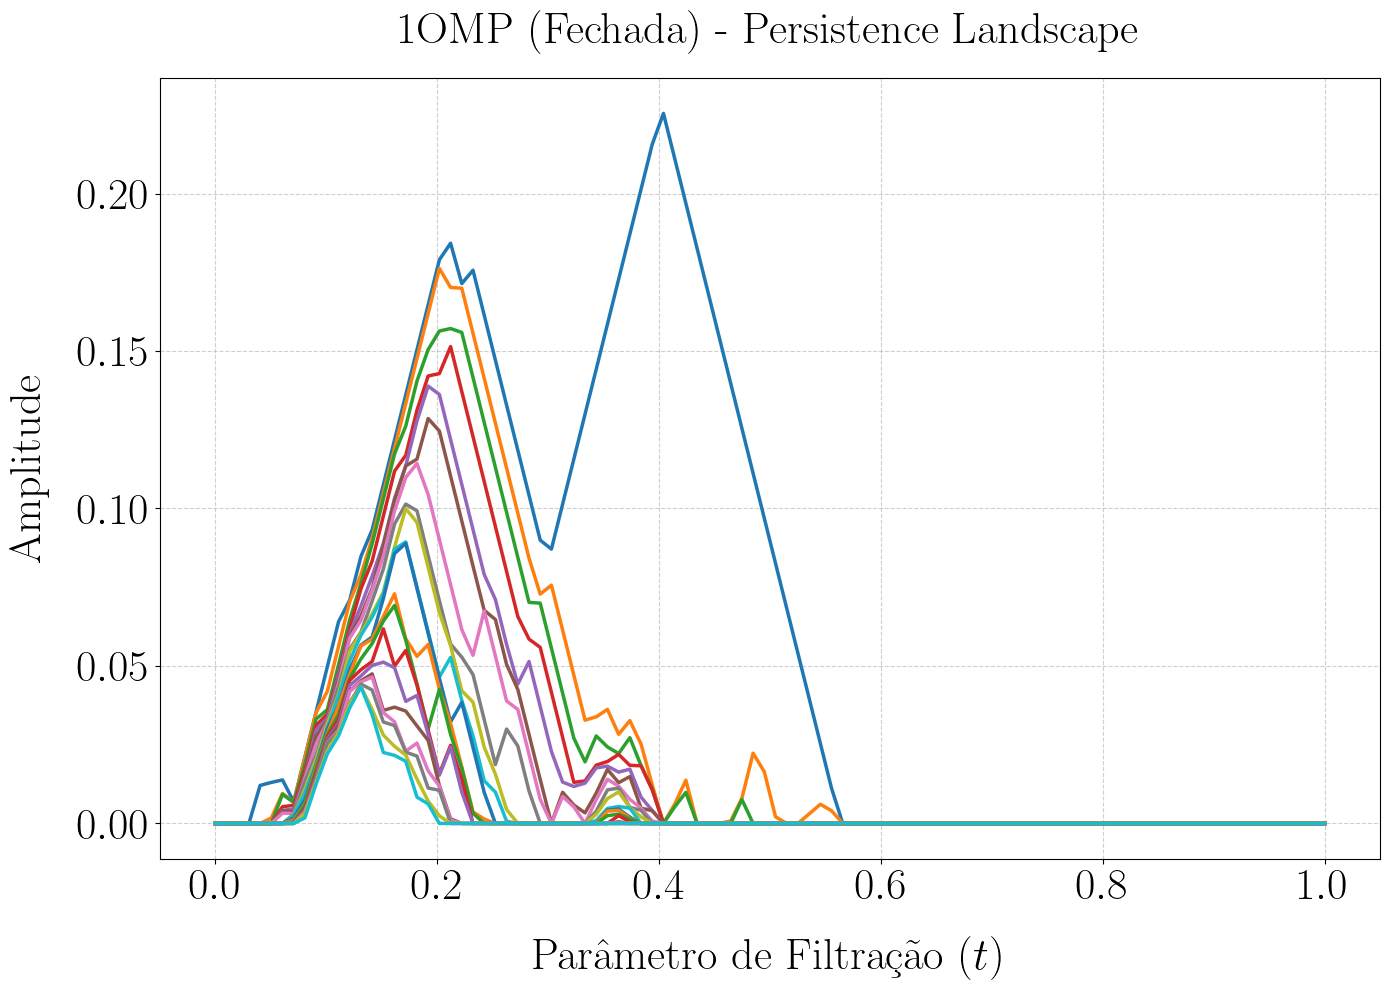

In [11]:

# 1. Parâmetros de controle para garantir que ambas tenham a mesma grade
resolution = 100
num_landscapes = 20  # Número de camadas a plotar
t_max = 1.0         # Limite superior da filtração

def encontrar_matriz(pdb_id):
    """Retorna (caminho, tipo) onde tipo é 'holo' ou 'apo'"""
    for pasta in ['holo', 'apo']:
        caminho = f"Dados/matrizes/{pasta}/{pdb_id}_matriz.npy"
        if os.path.exists(caminho):
            return caminho, pasta
    return None, None


def corr_to_dist(corr):

    D = 1.0 - np.abs(corr)
    # Garante simetria e diagonal zero (pode haver ruído numérico)
    np.fill_diagonal(D, 0.0)
    D = (D + D.T) / 2.0

    # Verifica se há valores negativos
    if np.any(D < 0):
        print("Aviso: valores negativos na matriz de distância. Aplicando clip.")
        D = np.clip(D, 0.0, None)
    return D

# 2. Função modificada para retornar a matriz de landscapes (e não achatada)
def extrair_landscape_matriz(D, grau=1, num_landscapes=num_landscapes, resolution=resolution, t_max=t_max):
    # (Seu código original de construção do complexo de Rips e persistência...)
    rips = gudhi.RipsComplex(distance_matrix=D, max_edge_length=t_max)
    st = rips.create_simplex_tree(max_dimension=grau + 1)
    st.persistence(homology_coeff_field=2)
    intervalos = st.persistence_intervals_in_dimension(grau)
    
    # Tratamento de infinitos
    intervalos_finitos = np.array([[b, d if np.isfinite(d) else t_max] for b, d in intervalos])
    
    if len(intervalos_finitos) == 0:
        return np.zeros((num_landscapes, resolution))

    # Transformação para o formato de landscape
    LS = Landscape(num_landscapes=num_landscapes, resolution=resolution, sample_range=[0, t_max])
    # O GUDHI espera uma lista de diagramas
    matriz_landscapes = LS.fit_transform([intervalos_finitos]) 
    
    # Reorganiza o vetor achatado de volta para (num_landscapes, resolution)
    return matriz_landscapes.reshape(num_landscapes, resolution)

# 3. Extração para as duas estruturas
# Supondo D_1ANF e D_1OMP como suas matrizes de distância
D_1ANF = corr_to_dist(np.load(encontrar_matriz('1ANF')[0]))
D_1OMP = corr_to_dist(np.load(encontrar_matriz('1OMP')[0]))
L_1ANF = extrair_landscape_matriz(D_1ANF)
L_1OMP = extrair_landscape_matriz(D_1OMP)

# 4. Plotagem Comparativa
# ==========================================================
TAMANHO_FONTE = 32

# Configuração global para os números dos eixos (ticks)
plt.rcParams['xtick.labelsize'] = TAMANHO_FONTE
plt.rcParams['ytick.labelsize'] = TAMANHO_FONTE

grade_x = np.linspace(0, t_max, resolution)

# ----------------------------------------------------------
# PLOT 1: 1ANF (Aberta)
# ----------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(14, 10)) # Tamanho grande para comportar a fonte

# Plota cada uma das camadas da Landscape
for i in range(num_landscapes):
    ax1.plot(grade_x, L_1ANF[i, :], linewidth=2.5)

# Título e eixos com espaçamentos (pad e labelpad) para evitar colisões
ax1.set_title("1ANF (Aberta) - Persistence Landscape", fontsize=TAMANHO_FONTE, pad=25, fontweight='bold')
ax1.set_xlabel(r"Parâmetro de Filtração ($t$)", fontsize=TAMANHO_FONTE, labelpad=20)
ax1.set_ylabel("Amplitude", fontsize=TAMANHO_FONTE, labelpad=20)
ax1.grid(True, linestyle="--", alpha=0.6)

# Ajusta as margens físicas da imagem para o texto não ser cortado nas bordas
plt.tight_layout()
plt.savefig('landscape_1ANF.png', dpi=300)
plt.show()


# ----------------------------------------------------------
# PLOT 2: 1OMP (Fechada)
# ----------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(14, 10))

# Plota cada uma das camadas da Landscape
for i in range(num_landscapes):
    ax2.plot(grade_x, L_1OMP[i, :], linewidth=2.5)

ax2.set_title("1OMP (Fechada) - Persistence Landscape", fontsize=TAMANHO_FONTE, pad=25, fontweight='bold')
ax2.set_xlabel(r"Parâmetro de Filtração ($t$)", fontsize=TAMANHO_FONTE, labelpad=20)
ax2.set_ylabel("Amplitude", fontsize=TAMANHO_FONTE, labelpad=20)
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig('landscape_1OMP.png', dpi=300)
plt.show()

In [3]:
def gerar_cadeia_simplexos():
    # Coordenadas fixas para formar um quadrado perfeito
    # a=(0,1) [topo-esq], b=(1,1) [topo-dir], c=(1,0) [baixo-dir], d=(0,0) [baixo-esq]
    vertices = {
        'a': np.array([0.0, 1.0]),
        'b': np.array([1.0, 1.0]),
        'c': np.array([1.0, 0.0]),
        'd': np.array([0.0, 0.0])
    }
    
    # Definição do que entra em cada etapa (acumulativo)
    etapas = {
        1:  {"v": ['a'],           "e": [],       "f": False}, # K^1: ponto a
        2:  {"v": ['a', 'b'],      "e": [],       "f": False}, # K^2: pontos a, b
        3:  {"v": ['a', 'b', 'c'], "e": [],       "f": False}, # K^3: pontos a, b, c
        4:  {"v": ['a', 'b', 'c', 'd'], "e": [],  "f": False}, # K^4: quadrado (só os 4 pontos)
        5:  {"v": ['a', 'b', 'c', 'd'], "e": [('a','b')], "f": False}, # K^5: aresta a-b
        6:  {"v": ['a', 'b', 'c', 'd'], "e": [('a','b'), ('b','c')], "f": False}, # K^6: aresta b-c
        7:  {"v": ['a', 'b', 'c', 'd'], "e": [('a','b'), ('b','c'), ('c','d')], "f": False}, # K^7: aresta c-d
        8:  {"v": ['a', 'b', 'c', 'd'], "e": [('a','b'), ('b','c'), ('c','d'), ('d','a')], "f": False}, # K^8: aresta d-a
        9:  {"v": ['a', 'b', 'c', 'd'], "e": [('a','b'), ('b','c'), ('c','d'), ('d','a'), ('b','d')], "f": False}, # K^9: diagonal b-d
        10: {"v": ['a', 'b', 'c', 'd'], "e": [('a','b'), ('b','c'), ('c','d'), ('d','a'), ('b','d')], "f": True}  # K^10: triângulo a-b-d preenchido
    }
    
    # Loop para gerar e salvar cada uma das 10 imagens
    for k in range(1, 11):
        fig, ax = plt.subplots(figsize=(6, 6))
        
        config = etapas[k]
        
        # 1. Desenhar o preenchimento (2-simplex) no K^10 se ativo
        if config["f"]:
            pts_triangulo = np.array([vertices['a'], vertices['b'], vertices['d']])
            polygon = plt.Polygon(pts_triangulo, closed=True, facecolor='darkblue', edgecolor='none', zorder=1)
            ax.add_patch(polygon)
            
        # 2. Desenhar as arestas (1-simplexos) presentes na etapa
        for v1, v2 in config["e"]:
            p1, p2 = vertices[v1], vertices[v2]
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='black', linewidth=3, zorder=2)
            
        # 3. Desenhar os vértices (0-simplexos) presentes na etapa
        for v in config["v"]:
            p = vertices[v]
            ax.scatter(p[0], p[1], color='black', s=180, zorder=3)
            
            # Label identificando o vértice (a, b, c, d) discretamente ao lado dele
            offset = 0.06
            if v == 'a': ha, va, ox, oy = 'right', 'bottom', -offset, offset
            elif v == 'b': ha, va, ox, oy = 'left', 'bottom', offset, offset
            elif v == 'c': ha, va, ox, oy = 'left', 'top', offset, -offset
            else: ha, va, ox, oy = 'right', 'top', -offset, -offset
            
            ax.text(p[0]+ox, p[1]+oy, rf'${v}$', fontsize=20, ha=ha, va=va, color='gray')
            
        # Configurações de layout
        ax.set_xlim(-0.3, 1.3)
        ax.set_ylim(-0.3, 1.3)
        ax.set_aspect('equal')
        ax.axis('off')
        
        # Título/Legenda EMBAIXO da imagem usando a notação matemática K^k requested
        plt.title(rf'$K^{{{k}}}$', y=-0.1, pad=-10, fontsize=45)
        
        # Ajuste de margens e salvamento em Alta Definição (dpi=300 garante o High-Res)
        plt.tight_layout()
        nome_arquivo = f"evolucao_complexo_K{k}.png"
        plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"Imagem {k}/10 salva com sucesso: {nome_arquivo}")

# Executa a função para gerar a cadeia de 10 imagens
gerar_cadeia_simplexos()

Imagem 1/10 salva com sucesso: evolucao_complexo_K1.png
Imagem 2/10 salva com sucesso: evolucao_complexo_K2.png
Imagem 3/10 salva com sucesso: evolucao_complexo_K3.png
Imagem 4/10 salva com sucesso: evolucao_complexo_K4.png
Imagem 5/10 salva com sucesso: evolucao_complexo_K5.png
Imagem 6/10 salva com sucesso: evolucao_complexo_K6.png
Imagem 7/10 salva com sucesso: evolucao_complexo_K7.png
Imagem 8/10 salva com sucesso: evolucao_complexo_K8.png
Imagem 9/10 salva com sucesso: evolucao_complexo_K9.png
Imagem 10/10 salva com sucesso: evolucao_complexo_K10.png
